# Publication figures: SHAP-IMV, Multi-IMV, Ablate-IMV, and GNN training

This is the single results-only notebook for the empirical publication figures and tables:

1. **SHAP-IMV:** one compact 3 x 3 ranking figure for Titanic, Breast Cancer, and Adult Income, top-five feature-selection comparisons, and the ranking and comparison LaTeX tables.
2. **Multi-IMV:** the latest heatmap/bar figures and classification tables for Car Evaluation, Dry Bean, and Nursery, including the manuscript LaTeX exports.
3. **Ablate-IMV:** a 2 x 3 overview for MNIST / CNN, UCI HAR / BiGRU, and MAGIC Gamma / MLP.
4. **GNN training:** mean curves with per-epoch seed ranges and individual-seed diagnostics for six graph datasets.

Only completed results are loaded; no datasets are downloaded and no models are trained. The optional `INSTALL_REQUIREMENTS` switch defaults to `False`. Complete the producers in `src/empirical/ablation_imv/`, `src/empirical/gnn/`, `src/empirical/multi_imv/`, and `src/empirical/shap_imv/` first. The runner executes this notebook last.

The combined SHAP PDF replaces the two split ranking figures; other PDF filenames, CSV filenames, LaTeX labels, and the shared project palette/font are preserved. Suggested captions accompany each section. Sections use separate result variables and settings so rerunning one does not overwrite another's data or style. Generated LaTeX files identify this notebook as their source.


In [67]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'requirements.txt').is_file()
    and (path / 'src' / 'empirical' / 'plotter' / 'figure_utils.py').is_file()
)
INSTALL_REQUIREMENTS = False
if INSTALL_REQUIREMENTS:
    %pip install -r "{PROJECT_ROOT / 'requirements.txt'}"

if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
import imvpy
from empirical.plotter import figure_utils
from empirical.plotter.figure_utils import (
    ABLATION_EXAMPLES, artifact_directory, figure_directory,
    load_ablation_results, plot_ablation_overview, save_publication_figure,
)

def relative_path(path, *, start=None):
    """Display paths relative to the project, independent of kernel cwd."""
    anchor = Path(start) if start is not None else PROJECT_ROOT
    try:
        relative = os.path.relpath(Path(path).expanduser().resolve(),
                                   start=anchor.expanduser().resolve())
    except ValueError:  # Different Windows drives cannot be relativized.
        relative = Path(path).name
    return Path(relative).as_posix()

ARTIFACT_ROOT = artifact_directory()
FIGURES = figure_directory(PROJECT_ROOT)
FIGURES.mkdir(parents=True, exist_ok=True)
FIGURE_NAME = 'figure_4'
print(f'imvpy {imvpy.__version__}')
print(f'Results: {relative_path(ARTIFACT_ROOT)}')
print(f'Figures: {relative_path(FIGURES)}')


TABLES = PROJECT_ROOT / 'output' / 'tables'
TABLES.mkdir(parents=True, exist_ok=True)
NOTEBOOK_PATH = 'src/empirical/plotter/plotter.ipynb'

def write_csv_atomic(table, path, *, index=False):
    """Replace a CSV only after its complete contents reach the same directory."""
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        table.to_csv(temporary, index=index)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)


def write_text_atomic(text, path):
    """Replace a file only after its complete contents reach the same directory."""
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        temporary.write_text(text)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)


def escape_latex(text):
    """Escape the characters that actually occur in these names."""
    replacements = {"\\": r"\textbackslash{}", "&": r"\&", "%": r"\%", "$": r"\$",
                    "#": r"\#", "_": r"\_", "{": r"\{", "}": r"\}",
                    "~": r"\textasciitilde{}", "^": r"\textasciicircum{}"}
    return "".join(replacements.get(character, character) for character in str(text))



imvpy 1.2.0
Results: ../../../../../../.cache/imv/notebook_artifacts
Figures: output/figures


## 1. SHAP-IMV — results across the three examples

Everything the three `src/empirical/shap_imv/*.ipynb` notebooks produced, gathered in one place: the top-5 feature-selection comparison as one LaTeX table, the SHAP-IMV ranking of the variables in each example as a second one, and one compact 3 x 3 figure showing those rankings.

Nothing is recomputed here. The tables are read back from `output/examples/shap/` and the artefact cache, so this notebook is cheap to re-run and uses the saved example results. Run the three example notebooks first if a file is missing.

Both `.tex` files are written to `output/tables/` as complete `table` environments, ready for `\input`. They are regenerated on every run, so any edit belongs in the constants below rather than in the file — the citation keys in particular.

The figure style — panel size, palette, weights, sizes, edge colour — comes from `src/empirical/plotter/figure_utils.py`, so any other notebook can import it and produce panels that sit beside these without retouching.

Optional setup: set `INSTALL_REQUIREMENTS = True` in the first code cell to install this project's requirements into the current kernel. It defaults to `False` so ordinary plotting runs do not install packages or require network access.

In [68]:
SHAP_OUTPUT = PROJECT_ROOT / "output" / "examples" / "shap"
SHAP_OUTPUT.mkdir(parents=True, exist_ok=True)

# Datasets in the column order of the table; each notebook is named for its
# example and its artefacts for the dataset slug inside it.
SHAP_EXAMPLES = {"shap_imv_titanic": ("titanic", "Titanic"),
            "shap_imv_breast_cancer": ("breast_cancer", "Breast Cancer"),
            "shap_imv_adult_income": ("adult_income", "Adult Income")}
SHAP_MODEL_NAMES = ("logistic_regression", "xgboost", "lightgbm")
SHAP_MODEL_LABELS = {"logistic_regression": "LR", "xgboost": "XGB", "lightgbm": "LGBM"}
SHAP_MODEL_TITLES = {"logistic_regression": "Logistic Regression",
                "xgboost": "XGBoost", "lightgbm": "LightGBM"}
SHAP_METHOD_NAMES = ("shap_imv", "shap", "lime", "anchors")
SHAP_METHOD_LABELS = {"shap_imv": "SHAP-IMV", "shap": "SHAP", "lime": "LIME",
                 "anchors": "Anchors"}
# The manuscript cites the three baselines in the text rather than in the table,
# so no key is emitted by default. Fill this in — {"shap": r"\cite{SHAP}"} and so
# on — to put them back; the keys have to exist in the bibliography, so edit them
# here rather than in the generated .tex, which every run overwrites.
SHAP_METHOD_CITATIONS = {}
SHAP_METRICS = {"accuracy_mean": "Accuracy", "precision_mean": "Precision"}
SHAP_TOP_K = 5
# Attribution uses N_SPLITS in the producers, not their top-k EVAL_SPLITS.
SHAP_ATTRIBUTION_SPLITS = 5

# Short display names for the ranking table; anything missing falls through to
# the raw column name, escaped.
SHAP_FEATURE_LABELS = {"AgeClass": r"Age$\times$Class", "Alone": "Alone",
                  "sex_female": "Sex (female)", "race_white": "Race (white)",
                  "age": "Age", "education-num": "Education",
                  "hours-per-week": "Hours/week", "married": "Married",
                  "capital-gain": "Capital gain", "capital-loss": "Capital loss",
                  "radius1": "Radius", "texture1": "Texture",
                  "smoothness1": "Smoothness", "compactness1": "Compactness",
                  "symmetry1": "Symmetry", "fractal_dimension1": "Fractal dim.",
                  "concavity1": "Concavity", "concave_points1": "Concave points"}



### 1.1. Load what the examples wrote

Each file is looked up under `output/examples/shap/` first and in the artefact cache second, so a checkout that ships only `output/` still renders everything: the per-feature SHAP-IMV summary lives in the cache, and where it is absent the ranking is recovered from the published top-5 table instead.

The per-example tables are then concatenated into two cross-example CSVs, which is the one thing this notebook adds rather than repeats.

In [ ]:
def read_shap_result(example, filename, **read_kwargs):
    """Read one artefact, preferring the published copy under output/."""
    candidates = [SHAP_OUTPUT / filename, ARTIFACT_ROOT / example / "results" / filename]
    for path in candidates:
        if path.is_file():
            return pd.read_csv(path, **read_kwargs)
    raise FileNotFoundError(
        f"{filename} is missing; run src/empirical/shap_imv/{example}.ipynb "
        f"first (looked in {', '.join(relative_path(path) for path in candidates)})")

def shap_ranking_from_top_k(top_k):
    """The SHAP-IMV ranking recovered from the published top-k table.

    The table keeps the selected features in order with their values and the
    dropped ones without, so the ranking survives in full and only the values
    below the cut are lost.
    """
    rows = []
    for _, row in top_k[top_k["method"] == "shap_imv"].iterrows():
        selected = row["selected_features"].split(";")
        values = [float(value) for value in row["importance"].split(";")]
        dropped = [name for name in str(row["dropped_features"]).split(";") if name]
        rows += [{"model": row["model"], "feature": name, "mean": value,
                  "std": np.nan} for name, value in zip(selected, values)]
        rows += [{"model": row["model"], "feature": name, "mean": np.nan,
                  "std": np.nan} for name in dropped]
    return pd.DataFrame(rows)

def load_shap_ranking(example, dataset, top_k):
    """Mean SHAP-IMV per feature and estimator, ranked, for one example."""
    try:
        summary = read_shap_result(example, f"{dataset}_shap_imv_summary.csv")
    except FileNotFoundError:
        summary = shap_ranking_from_top_k(top_k)
        print(f"  {example}: no per-feature summary in the cache; ranking read "
              f"off the top-{SHAP_TOP_K} table, so the dropped features carry no value")
    summary = summary[summary["model"].isin(SHAP_MODEL_NAMES)].copy()
    # Rank within an estimator, strongest first. A feature with no value — the
    # fallback above — sorts last, which is where the top-k table left it.
    summary["rank"] = (summary.groupby("model")["mean"]
                       .rank(ascending=False, method="first", na_option="bottom")
                       .astype(int))
    return summary.sort_values(["model", "rank"]).reset_index(drop=True)

def load_shap_example(example, dataset, title):
    """One example's top-k selection table and its SHAP-IMV feature ranking."""
    top_k = read_shap_result(example, f"{example}_top_{SHAP_TOP_K}_features.csv")
    missing = sorted({(model, method) for model in SHAP_MODEL_NAMES
                      for method in SHAP_METHOD_NAMES}
                     - set(map(tuple, top_k[["model", "method"]].to_numpy())))
    if missing:
        raise ValueError(f"{example}: no top-{SHAP_TOP_K} results for {missing}")
    return {"example": example, "dataset": dataset, "title": title,
            "top_k": top_k, "ranking": load_shap_ranking(example, dataset, top_k),
            "n_seeds": int(top_k["n_seeds"].iloc[0]),
            "n_splits": int(top_k["n_splits"].iloc[0])}

shap_results = {example: load_shap_example(example, dataset, title)
           for example, (dataset, title) in SHAP_EXAMPLES.items()}
# These CSV fields describe top-k refits only. Exact SHAP-IMV attribution
# uses SHAP_ATTRIBUTION_SPLITS, a separate five-fold protocol.
shap_protocol = {(result["n_seeds"], result["n_splits"]) for result in shap_results.values()}
if len(shap_protocol) != 1:
    raise ValueError(f"the examples disagree on seeds × folds: {sorted(shap_protocol)}")
SHAP_N_SEEDS, SHAP_N_SPLITS = shap_protocol.pop()
for result in shap_results.values():
    features = result["ranking"].query("model == 'logistic_regression'")["feature"]
    print(f"{result['title']:<15} {len(features)} features, {SHAP_N_SEEDS} seeds × "
          f"{SHAP_N_SPLITS} refit folds; {SHAP_ATTRIBUTION_SPLITS} attribution folds: "
          f"{', '.join(features)}")

shap_combined_top_k = pd.concat([result["top_k"] for result in shap_results.values()],
                           ignore_index=True)
shap_combined_ranking = pd.concat(
    [result["ranking"].assign(example=result["example"], dataset=result["title"])
     for result in shap_results.values()],
    ignore_index=True)[["example", "dataset", "model", "rank", "feature", "mean",
                        "std"]].rename(columns={"mean": "shap_imv_mean",
                                                "std": "shap_imv_std"})

for table, name in ((shap_combined_top_k, "top_k_metrics"),
                    (shap_combined_ranking, "feature_ranking")):
    write_csv_atomic(table, SHAP_OUTPUT / f"shap_imv_results__{name}.csv")
print(f"wrote two cross-example tables to {relative_path(SHAP_OUTPUT)}/")
shap_combined_ranking.head(12)

Titanic         8 features, 10 seeds × 10 refit folds; 5 attribution folds: Sex, Title, Class, AgeClass, Fare, Embarked, Alone, Age
Breast Cancer   8 features, 10 seeds × 10 refit folds; 5 attribution folds: concave_points1, radius1, concavity1, compactness1, texture1, smoothness1, symmetry1, fractal_dimension1
Adult Income    8 features, 10 seeds × 10 refit folds; 5 attribution folds: married, education-num, capital-gain, age, hours-per-week, sex_female, capital-loss, race_white
wrote two cross-example tables to output/examples/shap/


,example,dataset,model,rank,feature,shap_imv_mean,shap_imv_std
0,shap_imv_titanic,Titanic,lightgbm,1,Title,0.1127,0.001829
1,shap_imv_titanic,Titanic,lightgbm,2,Sex,0.1043,0.002058
2,shap_imv_titanic,Titanic,lightgbm,3,Fare,0.0531,0.005087
3,shap_imv_titanic,Titanic,lightgbm,4,Class,0.0458,0.001751
4,shap_imv_titanic,Titanic,lightgbm,5,AgeClass,0.0248,0.004185
5,shap_imv_titanic,Titanic,lightgbm,6,Embarked,0.0121,0.001729
6,shap_imv_titanic,Titanic,lightgbm,7,Alone,0.0087,0.000949
7,shap_imv_titanic,Titanic,lightgbm,8,Age,0.0008,0.003155
8,shap_imv_titanic,Titanic,logistic_regression,1,Sex,0.1466,0.002319
9,shap_imv_titanic,Titanic,logistic_regression,2,Title,0.0649,0.002558


### 1.2. Table 1: top-five feature selection

Table 1 compares SHAP-IMV, SHAP, LIME, and Anchors for logistic regression, XGBoost, and LightGBM on Titanic, Wisconsin Diagnostic Breast Cancer, and Adult Income. Each method selects five of the **eight specified predictors** using its seed-averaged ranking, then refits the same estimator. Accuracy and positive-class precision are percentages averaged over ten stratified folds for each of ten seeds; Average weights the three datasets equally.

**Protocol limitation:** preprocessing and feature selection use the full dataset before refit evaluation, rather than being nested within its folds. These are descriptive comparisons of fixed subsets, not unbiased estimates of an end-to-end feature-selection procedure's generalization performance. No uncertainty intervals or significance tests are reported in the table.

Within each estimator and column, **bold** denotes the best printed value and underline the second-best distinct value; ties share formatting, and columns in which all four methods agree are unmarked. The generated caption below is also used in the paper, via `tables/shap_imv_top_k.tex`.


In [ ]:
# Row striping, applied to every cell of every second row of a block, as in the
# manuscript. It needs \usepackage[table]{xcolor}; set it to None to drop that
# dependency and leave the rows unshaded.
SHAP_ROW_SHADE_COLOR = "gray!15"


def shap_method_label(method):
    """The method as the table prints it, with its citation where it has one."""
    citation = SHAP_METHOD_CITATIONS.get(method, "")
    return SHAP_METHOD_LABELS[method] + (f"~{citation}" if citation else "")

def shap_specification_note():
    """The sentence both captions carry about the fixed feature specification.

    Exact Shapley attribution evaluates one model per subset, so each example
    fixes a small specification rather than taking the dataset whole. Saying so
    in the caption keeps a reader from reading the ranking as a complete one.
    """
    widths = {result["title"]: int(result["ranking"]["rank"].max())
              for result in shap_results.values()}
    distinct = sorted(set(widths.values()))
    specification = (f"a fixed {distinct[0]}-variable specification"
                     if len(distinct) == 1 else
                     "a fixed specification ("
                     + ", ".join(f"{width} for {title}"
                                 for title, width in widths.items()) + ")")
    return (f"Each dataset uses {specification}, not all source variables; "
            "Breast Cancer denotes the Wisconsin Diagnostic dataset.")

def shap_metrics_matrix():
    """Percentages per (estimator, method) × (dataset, metric), plus the average.

    The average is over datasets, not over the pooled folds: each dataset counts
    once whatever its size, which is how the column is read.
    """
    titles = [title for _, title in SHAP_EXAMPLES.values()]
    wide = (shap_combined_top_k
            .assign(dataset=shap_combined_top_k["example"].map(lambda name: SHAP_EXAMPLES[name][1]))
            .pivot_table(index=["model", "method"], columns="dataset",
                         values=list(SHAP_METRICS)))
    matrix = pd.DataFrame({(title, metric): 100 * wide[(metric, title)]
                           for title in titles for metric in SHAP_METRICS})
    for metric in SHAP_METRICS:
        matrix[("Average", metric)] = np.mean(
            [matrix[(title, metric)] for title in titles], axis=0)
    matrix.columns = pd.MultiIndex.from_tuples(
        [(title, SHAP_METRICS[metric]) for title, metric in matrix.columns],
        names=["dataset", "metric"])
    return matrix.reindex(pd.MultiIndex.from_product([SHAP_MODEL_NAMES, SHAP_METHOD_NAMES],
                                                     names=["model", "method"]))

def shap_marked_cells(column):
    """`{method: latex}` for one column of one estimator block.

    Marks are applied to the printed value, so two methods that agree to two
    decimals are marked alike. A column whose four methods all agree separates
    nothing and is left plain.
    """
    values = column.round(2)
    distinct = sorted(set(values), reverse=True)
    best = distinct[0] if len(distinct) > 1 else None
    runner_up = distinct[1] if len(distinct) > 1 else None
    marks = {best: r"\textbf", runner_up: r"\underline"}
    return {method: (rf"{marks[value]}{{{value:.2f}}}" if value in marks
                     else f"{value:.2f}")
            for method, value in values.items()}

def shap_shaded(cells, position):
    """Every second row of a block carries the stripe on each of its cells."""
    if position % 2 == 0 or not SHAP_ROW_SHADE_COLOR:
        return cells
    return [rf"\cellcolor{{{SHAP_ROW_SHADE_COLOR}}}{cell}" for cell in cells]

def shap_metrics_latex(matrix):
    """The top-k selection table as the manuscript's full-width table environment."""
    datasets = list(dict.fromkeys(title for title, _ in matrix.columns))
    width = len(SHAP_METRICS)
    lines = [
        r"\begin{table*}[tp]",
        r"\centering",
        r"\tabcolsep=3pt",
        rf"\caption{{Predictive performance after top-{SHAP_TOP_K} feature selection "
        rf"by SHAP-IMV, SHAP, LIME, and Anchors. LR, XGB, and LGBM denote logistic "
        rf"regression, XGBoost, and LightGBM. {shap_specification_note()} "
        rf"Each method's seed-averaged ranking selects a fixed subset for refitting "
        rf"the same estimator. Accuracy and positive-class precision are percentages "
        rf"averaged over {SHAP_N_SPLITS} folds for each of {SHAP_N_SEEDS} seeds, using "
        rf"stratified cross-validation; Average weights the {len(SHAP_EXAMPLES)} "
        rf"datasets equally. Preprocessing and feature selection precede refit "
        rf"cross-validation and are not nested within its folds, so these are "
        rf"descriptive fixed-subset comparisons. Within each estimator and column, "
        rf"bold and underlining mark the best and second-best distinct values at "
        rf"the displayed precision; ties share formatting, and columns in which "
        rf"all methods agree are unmarked.}}",
        rf"\label{{{SHAP_METRICS_LABEL}}}",
        r"\resizebox{\textwidth}{!}{",
        r"    \begin{tabular}{" + "c" * (2 + len(matrix.columns)) + "}",
        r"        \toprule",
        r"         \multicolumn{2}{c}{\multirow{2}{*}{Methods}} & "
        + " & ".join(rf"\multicolumn{{{width}}}{{c}}{{{title}}}" for title in datasets)
        + r"\\",
        r"         &  & " + " & ".join(metric for _, metric in matrix.columns)
        + r" \\",
        r"        \midrule",
    ]
    for position, model in enumerate(SHAP_MODEL_NAMES):
        if position:
            lines.append(r"        \midrule")
        block = matrix.loc[model]
        marks = {column: shap_marked_cells(block[column]) for column in block.columns}
        lines.append(rf"        \multirow{{{len(SHAP_METHOD_NAMES)}}}{{*}}{{{SHAP_MODEL_LABELS[model]}}}")
        for offset, method in enumerate(SHAP_METHOD_NAMES):
            cells = shap_shaded([shap_method_label(method)]
                           + [marks[column][method] for column in block.columns],
                           offset)
            lines.append("        & " + " & ".join(cells) + r"\\")
    lines += [
        r"        \bottomrule",
        r"    \end{tabular}}",
        r"\end{table*}",
    ]
    return "\n".join(lines)

def shap_write_latex(body, path, *, packages):
    """Write a generated table, stamped with its source and its requirements."""
    header = (f"% Generated by {NOTEBOOK_PATH}; do not edit by hand.\n"
              f"% Requires: {', '.join(packages)}.\n")
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        temporary.write_text(header + body + "\n")
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)
    print(relative_path(path))
    return path

# \resizebox is graphicx; the stripe is the table option of xcolor.
SHAP_PACKAGES = [r"\usepackage{booktabs}", r"\usepackage{multirow}",
            r"\usepackage{graphicx}"] + ([r"\usepackage[table]{xcolor}"]
                                         if SHAP_ROW_SHADE_COLOR else [])
SHAP_METRICS_LABEL = "SHAPIMVTabulartable"
SHAP_RANKING_LABEL = "SHAPIMVRankingtable"

shap_metrics = shap_metrics_matrix()
shap_write_latex(shap_metrics_latex(shap_metrics), TABLES / "shap_imv_top_k.tex",
            packages=SHAP_PACKAGES)
print(shap_metrics_latex(shap_metrics))
display(shap_metrics.round(2)
        .rename(index=SHAP_MODEL_LABELS, level="model")
        .rename(index=SHAP_METHOD_LABELS, level="method"))

output/tables/shap_imv_top_k.tex
\begin{table*}[tp]
\centering
\tabcolsep=3pt
\caption{Predictive performance after top-5 feature selection by SHAP-IMV, SHAP, LIME, and Anchors. LR, XGB, and LGBM denote logistic regression, XGBoost, and LightGBM. Each dataset uses a fixed 8-variable specification, not all source variables; Breast Cancer denotes the Wisconsin Diagnostic dataset. Each method's seed-averaged ranking selects a fixed subset for refitting the same estimator. Accuracy and positive-class precision are percentages averaged over 10 folds for each of 10 seeds, using stratified cross-validation; Average weights the 3 datasets equally. Preprocessing and feature selection precede refit cross-validation and are not nested within its folds, so these are descriptive fixed-subset comparisons. Within each estimator and column, bold and underlining mark the best and second-best distinct values at the displayed precision; ties share formatting, and columns in which all methods agree are un

dataset         Titanic           Breast Cancer           Adult Income  \
metric         Accuracy Precision      Accuracy Precision     Accuracy   
model method                                                             
LR    SHAP-IMV    79.50     74.36         93.92     94.27        83.78   
      SHAP        79.74     73.95         94.10     94.46        83.78   
      LIME        79.74     73.95         94.10     94.46        84.16   
      Anchors     79.50     74.36         93.92     94.27        83.78   
XGB   SHAP-IMV    81.16     79.33         93.76     93.11        85.97   
      SHAP        81.16     79.33         94.22     93.34        85.29   
      LIME        80.44     80.47         94.22     93.34        85.98   
      Anchors     81.16     79.33         94.22     93.34        85.29   
LGBM  SHAP-IMV    81.00     79.48         93.97     93.41        86.00   
      SHAP        81.00     79.48         94.39     93.87        85.30   
      LIME        80.02     79.34         94.39     93.87        86.00   
      Anchors     81.00     79.48         94.39     93.87        85.30   

dataset                   Average            
metric         Precision Accuracy Precision  
model method                                 
LR    SHAP-IMV     70.94    85.73     79.85  
      SHAP         70.94    85.87     79.78  
      LIME         71.35    86.00     79.92  
      Anchors      70.94    85.73     79.85  
XGB   SHAP-IMV     79.42    86.96     83.95  
      SHAP         75.77    86.89     82.81  
      LIME         78.96    86.88     84.25  
      Anchors      75.77    86.89     82.81  
LGBM  SHAP-IMV     79.45    86.99     84.11  
      SHAP         75.91    86.90     83.09  
      LIME         79.03    86.80     84.08  
      Anchors      75.91    86.90     83.09

### 1.3. Table 2: SHAP-IMV feature ranking

Table 2 lists all eight predictors in descending order of mean SHAP-IMV for each dataset and estimator, with their exact Shapley contributions in parentheses. Means are over ten seeds, each using **five-fold stratified cross-validation for attribution**, not the ten-fold refits in Table 1. Ranks 1-5 form the fixed SHAP-IMV subset evaluated in Table 1; Figure 2 additionally shows the between-seed variation.

These rankings concern the restricted eight-predictor specifications, not every variable available in the source datasets. Missing values in a top-five fallback remain missing and are never invented. The generated caption below is also used in the paper, via `tables/shap_imv_ranking.tex`.


In [ ]:
def shap_feature_label(name):
    """The feature as the table prints it: a short label, or the escaped name."""
    return SHAP_FEATURE_LABELS.get(name, escape_latex(name))

def shap_ranking_cell(row):
    """One ranked feature: its label, and its mean SHAP-IMV where one survives."""
    label = shap_feature_label(row["feature"])
    if pd.isna(row["mean"]):
        return label
    # Separate labels and values so eight ranks remain readable at page width.
    return rf"\shortstack{{{label}\\({row['mean']:.3f})}}"

def shap_ranking_latex():
    """The SHAP-IMV ranking of every example, in the same table environment."""
    depth = int(shap_combined_ranking["rank"].max())
    lines = [
        r"\begin{table*}[tp]",
        r"\centering",
        r"\tabcolsep=3pt",
        rf"\caption{{Complete SHAP-IMV feature rankings for the three binary "
        rf"classification examples. LR, XGB, and LGBM denote logistic regression, "
        rf"XGBoost, and LightGBM. {shap_specification_note()} "
        rf"Predictors are ordered by decreasing mean exact Shapley contribution "
        rf"to model IMV, with means in parentheses to three decimals. Attribution "
        rf"uses {SHAP_ATTRIBUTION_SPLITS}-fold stratified cross-validation for each "
        rf"of {SHAP_N_SEEDS} seeds, distinct from the {SHAP_N_SPLITS}-fold refit "
        rf"evaluation in Table~\ref{{{SHAP_METRICS_LABEL}}}. Ranks 1--{SHAP_TOP_K} "
        rf"identify the fixed subset evaluated by that table's SHAP-IMV rows. "
        rf"Figure~\ref{{fig:SHAPIMV_Titanic}} plots the same means with one sample "
        rf"standard deviation across seeds. Rankings describe predictive "
        rf"contributions within each specification, not causal effects.}}",
        rf"\label{{{SHAP_RANKING_LABEL}}}",
        r"\resizebox{\textwidth}{!}{",
        r"    \begin{tabular}{" + "c" * (2 + depth) + "}",
        r"        \toprule",
        r"         \multirow{2}{*}{Dataset} & \multirow{2}{*}{Model} & "
        + rf"\multicolumn{{{depth}}}{{c}}{{Rank by mean SHAP-IMV}}\\",
        r"         &  & " + " & ".join(str(rank) for rank in range(1, depth + 1))
        + r" \\",
        r"        \midrule",
    ]
    for position, result in enumerate(shap_results.values()):
        if position:
            lines.append(r"        \midrule")
        title = escape_latex(result["title"]).replace(" ", r"\\")
        lines.append(rf"        \multirow[t]{{{len(SHAP_MODEL_NAMES)}}}{{*}}"
                     rf"{{\shortstack{{{title}}}}}")
        for offset, model in enumerate(SHAP_MODEL_NAMES):
            ranked = result["ranking"].query("model == @model").sort_values("rank")
            cells = [shap_ranking_cell(row) for _, row in ranked.iterrows()]
            cells += [""] * (depth - len(cells))   # a shorter feature set pads out
            lines.append("        & "
                         + " & ".join(shap_shaded([SHAP_MODEL_LABELS[model]] + cells, offset))
                         + r"\\")
            lines.append(r"        \addlinespace[2pt]")
    lines += [
        r"        \bottomrule",
        r"    \end{tabular}}",
        r"\end{table*}",
    ]
    return "\n".join(lines)

shap_write_latex(shap_ranking_latex(), TABLES / "shap_imv_ranking.tex", packages=SHAP_PACKAGES)
print(shap_ranking_latex())
display(shap_combined_ranking.pivot_table(
    index=["dataset", "model"], columns="rank", values="feature",
    aggfunc="first").reindex(
        [(result["title"], model) for result in shap_results.values()
         for model in SHAP_MODEL_NAMES]))

output/tables/shap_imv_ranking.tex
\begin{table*}[tp]
\centering
\tabcolsep=3pt
\caption{Complete SHAP-IMV feature rankings for the three binary classification examples. LR, XGB, and LGBM denote logistic regression, XGBoost, and LightGBM. Each dataset uses a fixed 8-variable specification, not all source variables; Breast Cancer denotes the Wisconsin Diagnostic dataset. Predictors are ordered by decreasing mean exact Shapley contribution to model IMV, with means in parentheses to three decimals. Attribution uses 5-fold stratified cross-validation for each of 10 seeds, distinct from the 10-fold refit evaluation in Table~\ref{SHAPIMVTabulartable}. Ranks 1--5 identify the fixed subset evaluated by that table's SHAP-IMV rows. Figure~\ref{fig:SHAPIMV_Titanic} plots the same means with one sample standard deviation across seeds. Rankings describe predictive contributions within each specification, not causal effects.}
\label{SHAPIMVRankingtable}
\resizebox{\textwidth}{!}{
    \begin{tabular}

rank                                             1                2  \
dataset       model                                                   
Titanic       logistic_regression              Sex            Title   
              xgboost                        Title              Sex   
              lightgbm                       Title              Sex   
Breast Cancer logistic_regression  concave_points1          radius1   
              xgboost              concave_points1          radius1   
              lightgbm                     radius1  concave_points1   
Adult Income  logistic_regression          married    education-num   
              xgboost                      married     capital-gain   
              lightgbm                     married     capital-gain   

rank                                           3             4  \
dataset       model                                              
Titanic       logistic_regression          Class      AgeClass   
              xgboost                       Fare         Class   
              lightgbm                      Fare         Class   
Breast Cancer logistic_regression     concavity1  compactness1   
              xgboost                 concavity1  compactness1   
              lightgbm                concavity1  compactness1   
Adult Income  logistic_regression   capital-gain           age   
              xgboost              education-num           age   
              lightgbm             education-num           age   

rank                                            5               6  \
dataset       model                                                 
Titanic       logistic_regression            Fare        Embarked   
              xgboost                    AgeClass        Embarked   
              lightgbm                   AgeClass        Embarked   
Breast Cancer logistic_regression        texture1     smoothness1   
              xgboost                    texture1     smoothness1   
              lightgbm                   texture1     smoothness1   
Adult Income  logistic_regression  hours-per-week      sex_female   
              xgboost                capital-loss  hours-per-week   
              lightgbm               capital-loss  hours-per-week   

rank                                          7                   8  
dataset       model                                                  
Titanic       logistic_regression         Alone                 Age  
              xgboost                     Alone                 Age  
              lightgbm                    Alone                 Age  
Breast Cancer logistic_regression     symmetry1  fractal_dimension1  
              xgboost                 symmetry1  fractal_dimension1  
              lightgbm                symmetry1  fractal_dimension1  
Adult Income  logistic_regression  capital-loss          race_white  
              xgboost                sex_female          race_white  
              lightgbm               sex_female          race_white

### 1.4. Figure 2: SHAP-IMV contributions to predictive fit

One compact 3 x 3 figure combines all three examples: Titanic, Breast Cancer, and Adult Income from top to bottom, with logistic regression, XGBoost, and LightGBM from left to right. Panels carry only bold, left-aligned letters `a.` to `i.`; the caption identifies the datasets and estimators.

The shorter panel height comes from `figure_utils.COMPACT_PANEL_HEIGHT`, and the shared PDF exporter applies `tight_layout`. The project palette, black bar outlines, dashed gridlines, and three-decimal mean annotations are unchanged.

Every feature with a saved score gets a bar; nothing is truncated here. Each example uses its fixed eight-feature specification, not the dataset's complete variable list. If only the top-five fallback is available, unscored features remain missing rather than being invented.

Y-axis limits are shared within each dataset row, not across datasets. Bars retain the saved mean SHAP-IMV and error bars show one standard deviation across seeds. A negative value means the feature reduced held-out information.

**Suggested Figure 2 caption.** SHAP-IMV contributions to predictive fit across datasets and estimators. Rows show Titanic (**a.**-**c.**), Breast Cancer (Wisconsin Diagnostic; **d.**-**f.**), and Adult Income (**g.**-**i.**); columns show logistic regression, XGBoost, and LightGBM, respectively. Each panel ranks the eight predictors in its fixed feature specification by mean SHAP-IMV: the Shapley-weighted marginal contribution to model IMV over all subsets of the remaining predictors. Scores are computed using five-fold stratified cross-validation for each of ten random seeds. Bar heights and numerical labels show means; whiskers show one sample standard deviation across seeds, not confidence intervals. Y-axis scales are shared within each dataset row.

**Protocol note.** Figure 2 uses the five-fold attribution runs (`N_SPLITS = 5` in the three source notebooks), not the separate ten-fold top-five-feature evaluation (`EVAL_SPLITS = 10`). The `n_splits` field in the top-five tables describes that latter evaluation and must not be used as the attribution fold count. The plotted Breast Cancer example is the Wisconsin Diagnostic dataset (UCI 17), not the Wisconsin Original dataset discussed in the older manuscript.

**Manuscript placement.** This caption accompanies `figures/figure_2.pdf` in `IMV_ML_paper/main.tex`. The existing `fig:SHAPIMV_Titanic` label is retained so current cross-references continue to resolve; it now identifies the combined three-dataset figure.



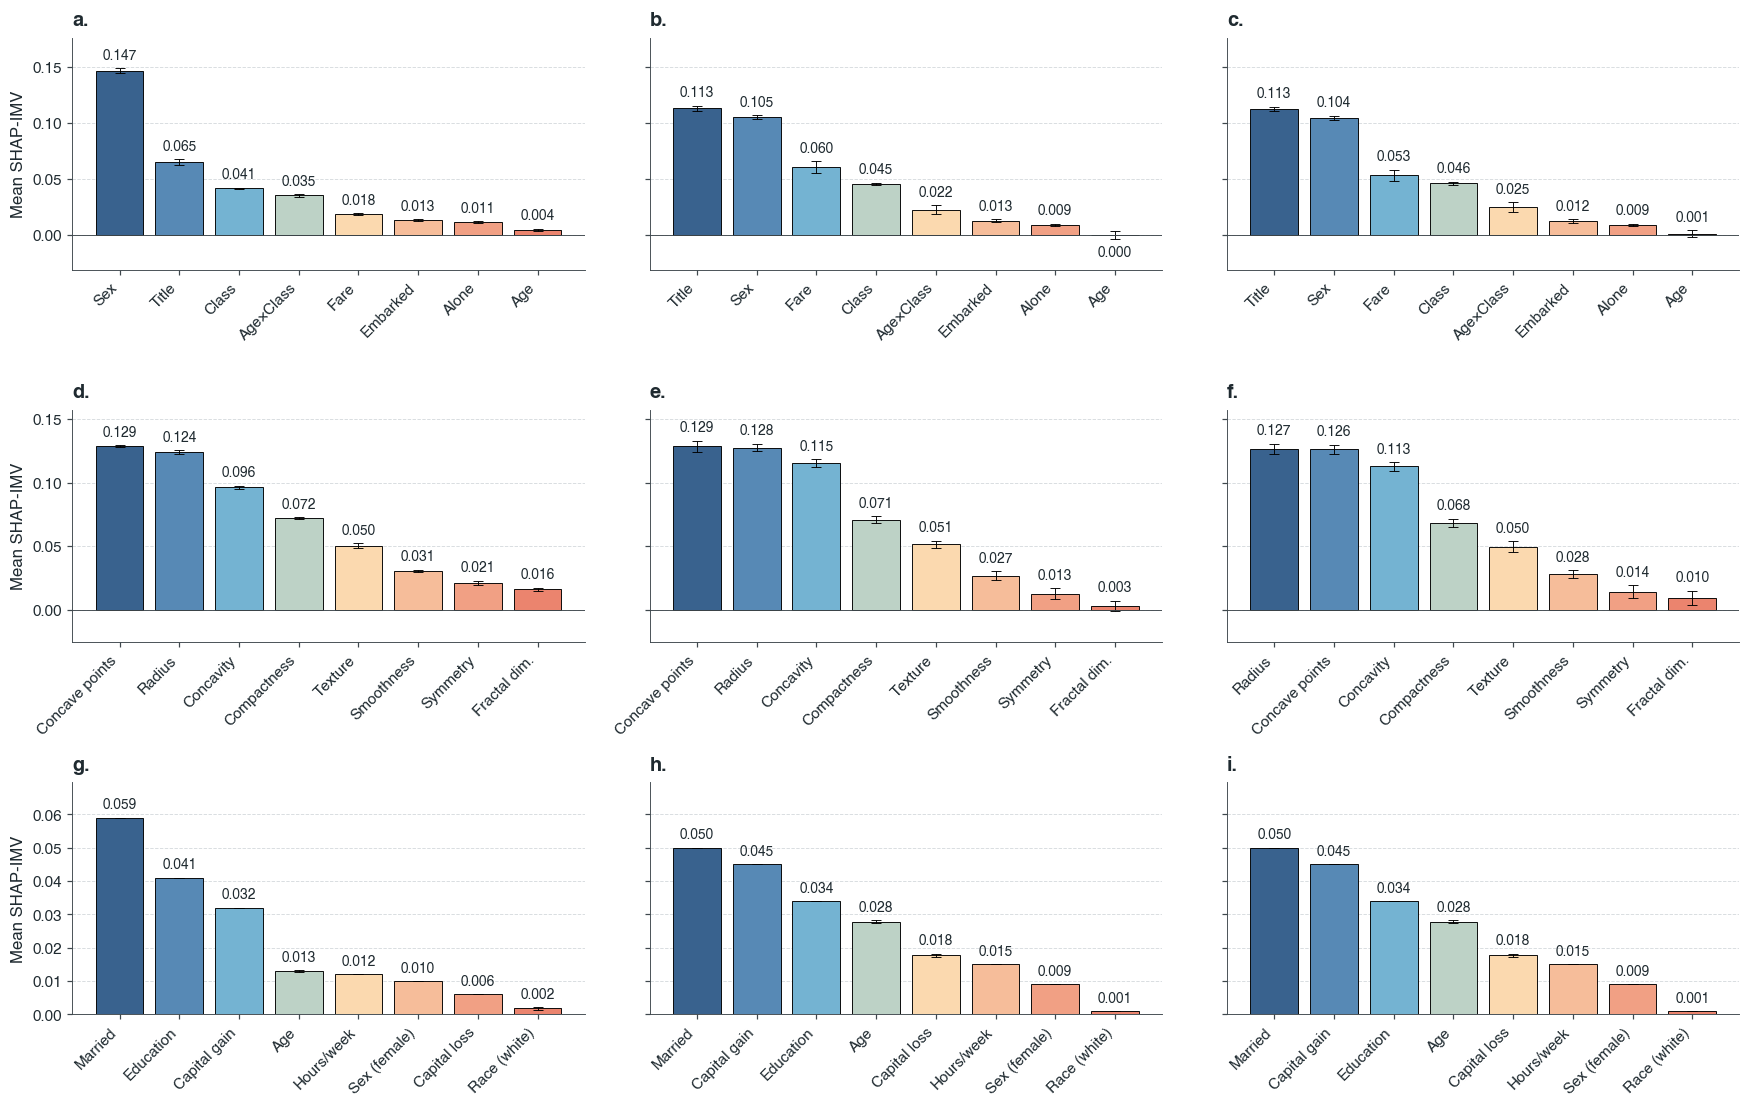

{'figure_2': 'output/figures/figure_2.pdf'}

In [72]:
# One compact 3x3 figure: datasets down rows, estimators across columns.
SHAP_FIGURE_GROUPS = (
    ("figure_2",
     ("shap_imv_titanic", "shap_imv_breast_cancer", "shap_imv_adult_income")),
)

def shap_ranking_figure(examples):
    """Mean SHAP-IMV per feature: one row per example, one column per estimator."""
    rows = [shap_results[example] for example in examples]
    figure, axes = plt.subplots(
        len(rows), len(SHAP_MODEL_NAMES),
        figsize=figure_utils.figure_size(
            len(rows), len(SHAP_MODEL_NAMES), height=figure_utils.COMPACT_PANEL_HEIGHT),
        sharey="row", squeeze=False)
    for row, result in enumerate(rows):
        for column, model in enumerate(SHAP_MODEL_NAMES):
            axis = axes[row, column]
            # dropna only bites on the fallback ranking, where a feature below
            # the cut has a rank but no value left to draw.
            ranked = (result["ranking"].query("model == @model")
                      .sort_values("rank").dropna(subset=["mean"]))
            labels = [SHAP_FEATURE_LABELS.get(name, name).replace(r"$\times$", "×")
                      for name in ranked["feature"]]
            spread = ranked["std"].fillna(0)
            figure_utils.plot_bars(axis, labels, ranked["mean"], yerr=spread)
            axis.set_xticks(range(len(labels)))
            axis.set_xticklabels(labels, rotation=45, ha="right")
            if column == 0:
                axis.set_ylabel("Mean SHAP-IMV", **figure_utils.LABEL_KWARGS)
        figure_utils.set_bar_limits(axes[row])
    figure_utils.label_panels(axes)
    return figure

def show_shap_figures():
    with plt.rc_context(figure_utils.rc_params()):
        written = {}
        for name, examples in SHAP_FIGURE_GROUPS:
            figure = shap_ranking_figure(examples)
            written[name] = save_publication_figure(figure, FIGURES / name)["pdf"]
            plt.show()
            plt.close(figure)
        if "figure_2" in written:
            # Retire the superseded exports only after the combined PDF saves.
            for stem in ("shap_imv_results__titanic",
                         "shap_imv_results__breast_cancer_adult_income",
                         "shap_imv_results__titanic_breast_cancer_adult_income"):
                (FIGURES / f"{stem}.pdf").unlink(missing_ok=True)
        return {name: relative_path(path) for name, path in written.items()}

shap_figure_paths = show_shap_figures()
shap_figure_paths


## 2. Multi-IMV — results across the three examples

Everything the three `src/empirical/multi_imv/*.ipynb` notebooks produced, gathered in one place: one metrics table per example, a 2×3 Dry Bean figure, and a combined 4×3 supplementary figure for Car Evaluation and Nursery — pairwise IMV heatmaps on the top row, one-vs-rest IMV bars on the bottom, one column per estimator.

Nothing is recomputed here. The tables and matrices are read back from `output/examples/multi_imv/` and the artefact cache, so this notebook is cheap to re-run and cannot disagree with the examples it summarises. Run the three example notebooks first if a file is missing.

The figure style — panel size, palette, weights, sizes, edge colour — comes from `src/empirical/plotter/figure_utils.py`, so any other notebook can import it and produce panels that sit beside these without retouching.

Dry Bean is the main-text **Figure 3**. Car Evaluation and Nursery share **Supplementary Figure A4**. Its combined export and caption follow section 2.5; the Figure 3 caption is in section 2.4.

Car Evaluation is main-text **Table 3**, displayed in section 2.3 and exported in section 2.6. Its manuscript source is `tables/multi_imv_car_evaluation.tex`; the other two metrics tables remain additional exports, not additional main-text tables.


In [73]:
MULTI_OUTPUT = PROJECT_ROOT / "output" / "examples" / "multi_imv"
MULTI_OUTPUT.mkdir(parents=True, exist_ok=True)

MULTI_MODEL_NAMES = ("logistic_regression", "xgboost", "lightgbm")
MULTI_MODEL_LABELS = {"logistic_regression": "Logistic regression",
                "xgboost": "XGBoost", "lightgbm": "LightGBM"}
# Panels are referred to by letter (column) and row in the caption.
MULTI_EXAMPLES = {"car_evaluation": "Car Evaluation", "dry_bean": "Dry Bean",
            "nursery": "Nursery"}
# One main-text figure and one combined supplementary figure.
MULTI_FIGURE_FILES = {"dry_bean": "figure_3"}
MULTI_SUPPLEMENTARY_EXAMPLES = ("car_evaluation", "nursery")
MULTI_SUPPLEMENTARY_FIGURE = "figure_A4"
MULTI_GLOBAL_LABELS = {"f1_weighted": "F1 Score", "roc_auc_ovr_weighted": "AUC-ROC",
                 "log_loss": "Log Loss", "hamming_loss": "Hamming Loss",
                 "cohens_kappa": "Cohen's Kappa", "jaccard_weighted": "Jaccard"}
# Rates keep the percentage reading the example notebooks give them; IMV, Brier
# loss and log loss stay on their own scale.
MULTI_PERCENT_METRICS = {"f1_weighted", "roc_auc_ovr_weighted", "cohens_kappa",
                   "jaccard_weighted"}



### 2.1. Load what the examples wrote

Each file is looked up under `output/examples/multi_imv/` first and in the artefact cache second, so a checkout that ships only `output/` still renders everything except the pairwise matrices, which live in the cache alone.

The per-example tables are then concatenated into four cross-example CSVs, which is the one thing this notebook adds rather than repeats.

In [ ]:
def read_multi_result(dataset, filename, **read_kwargs):
    """Read one artefact, preferring the published copy under output/."""
    candidates = [MULTI_OUTPUT / filename,
                  ARTIFACT_ROOT / f"multi_imv_{dataset}" / "results" / filename]
    for path in candidates:
        if path.is_file():
            return pd.read_csv(path, **read_kwargs)
    raise FileNotFoundError(
        f"{filename} is missing; run src/empirical/multi_imv/multi_imv_{dataset}.ipynb "
        f"first (looked in {', '.join(relative_path(path) for path in candidates)})")

def load_multi_example(dataset, title):
    """One example's tables, matrices and class names, as the figures need them."""
    class_summary = read_multi_result(dataset, f"{dataset}_class_metrics_summary.csv")
    class_names = (class_summary[["class", "class_name"]].drop_duplicates()
                   .sort_values("class")["class_name"].tolist())
    by_seed = read_multi_result(dataset, f"{dataset}_one_vs_rest_by_seed.csv")
    ova_summary = (by_seed.groupby(["model", "class"])["one_vs_rest_imv"]
                   .agg(["mean", "std"]).reset_index())
    pairwise = {name: read_multi_result(dataset, f"{dataset}_pairwise_imv_{name}.csv",
                                  index_col=0)
                for name in MULTI_MODEL_NAMES}
    missing = sorted(set(MULTI_MODEL_NAMES) - set(ova_summary["model"]))
    if missing:
        raise ValueError(f"{dataset}: no one-vs-rest results for {missing}")
    return {
        "dataset": dataset, "title": title, "class_names": class_names,
        "n_seeds": int(by_seed["seed"].nunique()),
        "class_summary": class_summary, "ova_summary": ova_summary,
        "pairwise": pairwise,
        "table": read_multi_result(dataset, f"{dataset}_metrics_table.csv").set_index("Methods"),
        "global_summary": read_multi_result(dataset, f"{dataset}_global_metrics_summary.csv"),
    }

multiclass_results = {dataset: load_multi_example(dataset, title) for dataset, title in MULTI_EXAMPLES.items()}
for result in multiclass_results.values():
    print(f"{result['title']:<15} {len(result['class_names'])} classes, "
          f"{result['n_seeds']} seeds, {len(result['pairwise'])} models: "
          f"{', '.join(result['class_names'])}")

def tag_multi_table(result, table):
    """A copy of `table` carrying the example it came from as its first columns."""
    tagged_table = table.copy()
    tagged_table.insert(0, "dataset", result["title"])
    tagged_table.insert(0, "example", f"multi_imv_{result['dataset']}")
    return tagged_table

combined_class = pd.concat(
    [tag_multi_table(result, result["class_summary"]) for result in multiclass_results.values()],
    ignore_index=True)
combined_global = pd.concat(
    [tag_multi_table(result, result["global_summary"]) for result in multiclass_results.values()],
    ignore_index=True)
combined_ova = pd.concat(
    [tag_multi_table(result, result["ova_summary"].assign(
        class_name=lambda part: [result["class_names"][int(value)]
                                 for value in part["class"]]))
     for result in multiclass_results.values()],
    ignore_index=True).rename(columns={"mean": "one_vs_rest_imv_mean",
                                       "std": "one_vs_rest_imv_std"})
# The matrices go out long rather than as three square blocks per example, so a
# reader can filter to one pair of classes across every example and estimator.
combined_pairwise = pd.concat(
    [tag_multi_table(result, pd.DataFrame(
        [{"model": name, "class_i": row, "class_j": column,
          "class_i_name": result["class_names"][int(row)],
          "class_j_name": result["class_names"][int(column)],
          "pairwise_imv": matrix.loc[row, column]}
         for name, matrix in result["pairwise"].items()
         for row in matrix.index for column in matrix.columns]))
     for result in multiclass_results.values()],
    ignore_index=True)

for table, name in ((combined_class, "class_metrics_summary"),
                    (combined_global, "global_metrics_summary"),
                    (combined_ova, "one_vs_rest_summary"),
                    (combined_pairwise, "pairwise_imv")):
    write_csv_atomic(table, MULTI_OUTPUT / f"multi_imv_results__{name}.csv")
print(f"wrote four cross-example tables to {relative_path(MULTI_OUTPUT)}/")
combined_global

Car Evaluation  4 classes, 10 seeds, 3 models: unacc, acc, good, vgood
Dry Bean        7 classes, 10 seeds, 3 models: BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SEKER, SIRA
Nursery         3 classes, 10 seeds, 3 models: not_recom, priority, spec_prior
wrote four cross-example tables to output/examples/multi_imv/


,example,dataset,model,f1_weighted_mean,f1_weighted_std,roc_auc_ovr_weighted_mean,roc_auc_ovr_weighted_std,log_loss_mean,log_loss_std,hamming_loss_mean,hamming_loss_std,cohens_kappa_mean,cohens_kappa_std,jaccard_weighted_mean,jaccard_weighted_std
0,multi_imv_car_evaluation,Car Evaluation,lightgbm,0.978878,0.001825,0.998987,0.000383,0.083345,0.002867,0.021412,0.001850,0.953815,0.003967,0.959437,0.003370
1,multi_imv_car_evaluation,Car Evaluation,logistic_regression,0.638436,0.003208,0.772946,0.001223,0.686837,0.001441,0.310243,0.002994,0.163148,0.007824,0.524194,0.003111
2,multi_imv_car_evaluation,Car Evaluation,xgboost,0.966933,0.002931,0.997136,0.000461,0.140061,0.001987,0.033449,0.002961,0.927912,0.006321,0.937598,0.005149
3,multi_imv_dry_bean,Dry Bean,lightgbm,0.927541,0.001064,0.994102,0.000059,0.196134,0.001138,0.072463,0.001074,0.912324,0.001303,0.866559,0.001825
4,multi_imv_dry_bean,Dry Bean,logistic_regression,0.924279,0.000380,0.993396,0.000028,0.214056,0.000595,0.075850,0.000383,0.908277,0.000464,0.860990,0.000632
5,multi_imv_dry_bean,Dry Bean,xgboost,0.927348,0.000824,0.994171,0.000062,0.192952,0.000931,0.072647,0.000833,0.912100,0.001012,0.866238,0.001427
6,multi_imv_nursery,Nursery,lightgbm,0.997641,0.000603,0.999986,0.000012,0.056726,0.000635,0.002359,0.000603,0.996460,0.000904,0.995299,0.001197
7,multi_imv_nursery,Nursery,logistic_regression,0.787415,0.000526,0.917658,0.000065,0.392640,0.000126,0.212510,0.000528,0.681053,0.000791,0.678735,0.000601
8,multi_imv_nursery,Nursery,xgboost,0.994031,0.000525,0.999916,0.000011,0.080378,0.000492,0.005970,0.000525,0.991043,0.000788,0.988170,0.001032


### 2.2. Table and figure for one example

The figure is a 2×3 grid: the top row is the pairwise IMV matrix per estimator, the bottom row the one-vs-rest IMV per class, with the spread across seeds as the error bar.

The two rows are **not on the same scale** and must not be read against each other. The one-vs-rest null model already knows the class base rate, so it starts above chance; pairwise renormalisation leaves its null at the 0.5 chance floor. Identical predictive power therefore reads lower on the bottom row. Within the top row the three matrices share one colour scale, so estimators can be compared cell by cell.

In [75]:
def format_global_metrics(summary):
    """The global metrics of one example as one line per estimator."""
    indexed = summary.set_index("model")
    lines = []
    for name in MULTI_MODEL_NAMES:
        row = indexed.loc[name]
        cells = []
        for metric, label in MULTI_GLOBAL_LABELS.items():
            scale = 100 if metric in MULTI_PERCENT_METRICS else 1
            deviation = row[f"{metric}_std"]
            cells.append(f"{label}: {scale * row[f'{metric}_mean']:.2f}"
                         f"±{scale * (0.0 if pd.isna(deviation) else deviation):.2f}")
        lines.append(f"{MULTI_MODEL_LABELS[name]}: " + "; ".join(cells))
    return "\n".join(lines)

def example_figure(result):
    """One dataset, using the same layout as the combined supplement."""
    return figure_utils.plot_multiclass_overview((result,), MULTI_MODEL_NAMES)

def show_example(dataset):
    """Show per-example metrics; only Dry Bean has a standalone overview."""
    result = multiclass_results[dataset]
    print(f"{result['title']}: per-class metrics, mean over {result['n_seeds']} "
          "seeds ± spread across seeds")
    display(result["table"])
    print(format_global_metrics(result["global_summary"]))
    if dataset not in MULTI_FIGURE_FILES:
        return None  # The two SI examples are plotted together below.
    with plt.rc_context(figure_utils.rc_params()):
        figure = example_figure(result)
        try:
            stem = MULTI_FIGURE_FILES[dataset]
            paths = save_publication_figure(figure, FIGURES / stem)
            # Retire the previous combined export only after its replacement exists.
            (FIGURES / f"multi_imv_results__{dataset}.pdf").unlink(missing_ok=True)
            plt.show()
        finally:
            plt.close(figure)
    return {file_format: relative_path(path) for file_format, path in paths.items()}

def show_multi_supplement():
    """Save both SI datasets once, with continuous panel labels a. through l."""
    rows = [multiclass_results[dataset] for dataset in MULTI_SUPPLEMENTARY_EXAMPLES]
    with plt.rc_context(figure_utils.rc_params()):
        figure = figure_utils.plot_multiclass_overview(rows, MULTI_MODEL_NAMES)
        try:
            paths = save_publication_figure(figure, FIGURES / MULTI_SUPPLEMENTARY_FIGURE)
            # Retire separate overviews only after the combined PDF saves.
            obsolete = ["figure_A5.pdf"] + [
                f"multi_imv_results__{dataset}.pdf" for dataset in MULTI_SUPPLEMENTARY_EXAMPLES
            ]
            for filename in obsolete:
                (FIGURES / filename).unlink(missing_ok=True)
            plt.show()
        finally:
            plt.close(figure)
    return {file_format: relative_path(path) for file_format, path in paths.items()}


### 2.3. Table 3: Car Evaluation

This is **Table 3 in the main paper**, not a third SHAP table. It reports one-vs-rest Multi-IMV, Brier loss, accuracy, precision, and recall for logistic regression, XGBoost, and LightGBM, followed by global classification metrics.

Four ordered classes are retained; the two rare classes (`good`, `vgood`) hold 134 of 1,728 rows. Logistic regression never predicts `good`: its one-vs-rest accuracy is 96.01%, but precision and recall are both zero. Its `vgood` recall is 21.23%; the two boosting models recover both rare classes much more often. High one-vs-rest accuracy alone therefore does not imply that a rare class is recognized.

**Caption and protocol.** Values are means and sample standard deviations across ten seeds, each using five-fold stratified cross-validation, not confidence intervals. IMV compares the feature-based model with the same estimator fitted to a constant input. IMV is averaged over folds within each seed; the other metrics use pooled out-of-fold predictions. Class accuracy, precision, and recall use the multiclass argmax prediction recoded one-vs-rest and are displayed as percentages. The complete reusable LaTeX caption is generated in section 2.6.

**Manuscript mapping.** `output/tables/multi_imv_car_evaluation.tex` is included as `tables/multi_imv_car_evaluation.tex` in the Overleaf paper, using `tab:MultiIMVCarEvaluation`. LaTeX assigns the number 3 automatically after the two SHAP tables. The paper and notebook use the same exported values and caption.

Car Evaluation also forms panels **a.** to **f.** of **Supplementary Figure A4**, exported with Nursery after section 2.5.


In [ ]:
show_example("car_evaluation")

Car Evaluation: per-class metrics, mean over 10 seeds ± spread across seeds


,unacc,acc,good,vgood
Methods,,,,
Multi-IMV (LR),0.15±0.00,0.05±0.00,0.00±0.00,0.02±0.00
Brier Loss (LR),0.17±0.00,0.16±0.00,0.04±0.00,0.03±0.00
Accuracy (LR),72.16±0.31,74.30±0.34,96.01±0.00,95.48±0.08
Precision (LR),74.51±0.19,34.99±1.34,0.00±0.00,33.91±1.74
Recall (LR),91.58±0.33,18.23±0.78,0.00±0.00,21.23±1.21
Multi-IMV (XGB),0.40±0.00,0.25±0.00,0.03±0.00,0.04±0.00
Brier Loss (XGB),0.02±0.00,0.03±0.00,0.01±0.00,0.01±0.00
Accuracy (XGB),97.84±0.20,97.06±0.24,98.87±0.20,99.54±0.14
Precision (XGB),99.32±0.20,91.93±0.89,83.67±1.77,91.85±2.50


Logistic regression: F1 Score: 63.84±0.32; AUC-ROC: 77.29±0.12; Log Loss: 0.69±0.00; Hamming Loss: 0.31±0.00; Cohen's Kappa: 16.31±0.78; Jaccard: 52.42±0.31
XGBoost: F1 Score: 96.69±0.29; AUC-ROC: 99.71±0.05; Log Loss: 0.14±0.00; Hamming Loss: 0.03±0.00; Cohen's Kappa: 92.79±0.63; Jaccard: 93.76±0.51
LightGBM: F1 Score: 97.89±0.18; AUC-ROC: 99.90±0.04; Log Loss: 0.08±0.00; Hamming Loss: 0.02±0.00; Cohen's Kappa: 95.38±0.40; Jaccard: 95.94±0.34


### 2.4. Dry Bean

Seven classes over 16 continuous morphological features. The three estimators land within a fraction of a point of each other, so the interesting variation is across classes rather than across models.

**Suggested caption for Figure 3.** Multi-IMV on Dry Bean, using all seven varieties and 16 morphological features. Columns show logistic regression, XGBoost, and LightGBM, respectively. Panels **a.** to **c.** show pairwise Multi-IMV for the classes identified by the row and column labels; both models' probabilities are renormalized within each class pair. The matrices are symmetric, with self-comparisons set to zero by convention, and share one colour scale. Panels **d.** to **f.** show one-vs-rest IMV for each class against all remaining classes. Both measures compare the feature-based model with the same estimator fitted to a constant input only. Cell values and bar heights are means across ten random seeds (42-51), each evaluated using five-fold stratified cross-validation. Whiskers denote one sample standard deviation across the ten seed-level fold means, not confidence intervals. Bar annotations report the means.

PDF: `output/figures/figure_3.pdf`.


Dry Bean: per-class metrics, mean over 10 seeds ± spread across seeds


,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
Methods,,,,,,,
Multi-IMV (LR),0.10±0.00,0.04±0.00,0.13±0.00,0.32±0.00,0.16±0.00,0.17±0.00,0.21±0.00
Brier Loss (LR),0.01±0.00,0.00±0.00,0.01±0.00,0.03±0.00,0.01±0.00,0.01±0.00,0.04±0.00
Accuracy (LR),98.55±0.03,100.00±0.00,98.53±0.01,95.83±0.03,98.71±0.01,98.45±0.02,94.76±0.04
Precision (LR),94.22±0.13,100.00±0.00,93.41±0.10,92.28±0.06,95.47±0.10,94.93±0.10,85.61±0.12
Recall (LR),90.63±0.22,99.96±0.08,94.36±0.06,91.66±0.06,95.41±0.06,94.68±0.08,87.69±0.12
Multi-IMV (XGB),0.10±0.00,0.04±0.00,0.13±0.00,0.33±0.00,0.16±0.00,0.17±0.00,0.21±0.00
Brier Loss (XGB),0.01±0.00,0.00±0.00,0.01±0.00,0.03±0.00,0.01±0.00,0.01±0.00,0.03±0.00
Accuracy (XGB),98.73±0.06,99.98±0.01,98.65±0.05,95.75±0.07,98.76±0.03,98.57±0.04,95.04±0.07
Precision (XGB),94.62±0.40,99.64±0.11,94.12±0.29,90.94±0.17,95.95±0.15,95.49±0.19,87.56±0.22


Logistic regression: F1 Score: 92.43±0.04; AUC-ROC: 99.34±0.00; Log Loss: 0.21±0.00; Hamming Loss: 0.08±0.00; Cohen's Kappa: 90.83±0.05; Jaccard: 86.10±0.06
XGBoost: F1 Score: 92.73±0.08; AUC-ROC: 99.42±0.01; Log Loss: 0.19±0.00; Hamming Loss: 0.07±0.00; Cohen's Kappa: 91.21±0.10; Jaccard: 86.62±0.14
LightGBM: F1 Score: 92.75±0.11; AUC-ROC: 99.41±0.01; Log Loss: 0.20±0.00; Hamming Loss: 0.07±0.00; Cohen's Kappa: 91.23±0.13; Jaccard: 86.66±0.18


Validated: dry_bean unchanged values; all labels fit.


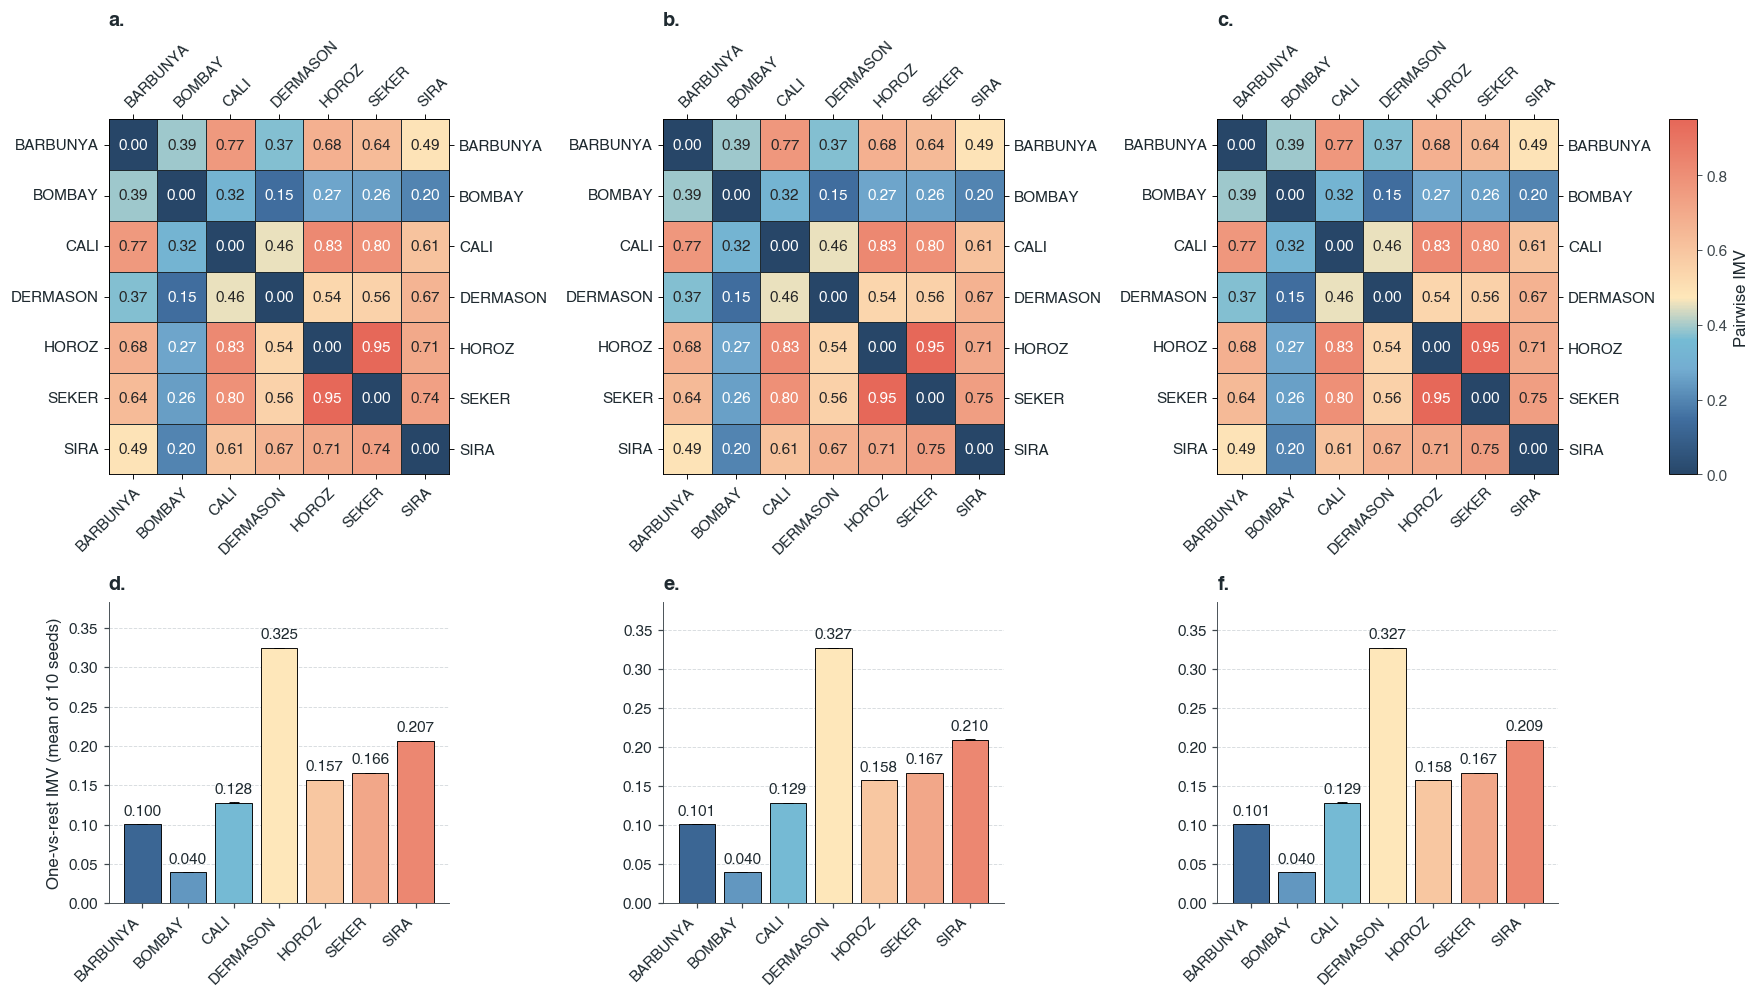

{'pdf': 'output/figures/figure_3.pdf'}

In [ ]:
show_example("dry_bean")

### 2.5. Nursery

Three classes, after dropping the two negligible ones as the original analysis did. `not_recom` is separable by a single feature, which is why every estimator resolves it exactly and the interest sits in the `priority`/`spec_prior` pair.

**Suggested caption for Supplementary Figure A4.** Multi-IMV on Car Evaluation (panels **a.** to **f.**) and Nursery (panels **g.** to **l.**). Car Evaluation retains all four outcome classes and six categorical predictors. Nursery uses eight categorical predictors and retains not_recom, priority, and spec_prior, excluding the rare recommend and very_recom classes. Columns show logistic regression, XGBoost, and LightGBM, respectively. Panels **a.** to **c.** and **g.** to **i.** show pairwise Multi-IMV for the row and column classes; null and feature-based probabilities are renormalized within each pair. Each dataset has its own colour scale, shared across its three heatmaps. Matrices are symmetric, with self-comparisons set to zero by convention. Panels **d.** to **f.** and **j.** to **l.** show one-vs-rest IMV for each class against the remaining classes. Both measures compare the feature-based model with the same estimator fitted to a constant input only. Cell values and bar heights are means across ten random seeds (42-51), each evaluated using five-fold stratified cross-validation. Whiskers denote one sample standard deviation across the ten seed-level fold means, not confidence intervals. Bar annotations report the means.

PDF: `output/figures/figure_A4.pdf` (4 rows by 3 columns).


Nursery: per-class metrics, mean over 10 seeds ± spread across seeds


,not_recom,priority,spec_prior
Methods,,,
Multi-IMV (LR),0.52±0.00,0.31±0.00,0.28±0.00
Brier Loss (LR),0.00±0.00,0.13±0.00,0.13±0.00
Accuracy (LR),100.00±0.00,78.75±0.05,78.75±0.05
Precision (LR),100.00±0.00,68.20±0.07,67.16±0.10
Recall (LR),100.00±0.00,69.48±0.12,65.82±0.10
Multi-IMV (XGB),0.52±0.00,0.49±0.00,0.45±0.00
Brier Loss (XGB),0.00±0.00,0.02±0.00,0.02±0.00
Accuracy (XGB),100.00±0.00,99.40±0.05,99.40±0.05
Precision (XGB),100.00±0.00,99.92±0.03,98.24±0.16


Logistic regression: F1 Score: 78.74±0.05; AUC-ROC: 91.77±0.01; Log Loss: 0.39±0.00; Hamming Loss: 0.21±0.00; Cohen's Kappa: 68.11±0.08; Jaccard: 67.87±0.06
XGBoost: F1 Score: 99.40±0.05; AUC-ROC: 99.99±0.00; Log Loss: 0.08±0.00; Hamming Loss: 0.01±0.00; Cohen's Kappa: 99.10±0.08; Jaccard: 98.82±0.10
LightGBM: F1 Score: 99.76±0.06; AUC-ROC: 100.00±0.00; Log Loss: 0.06±0.00; Hamming Loss: 0.00±0.00; Cohen's Kappa: 99.65±0.09; Jaccard: 99.53±0.12


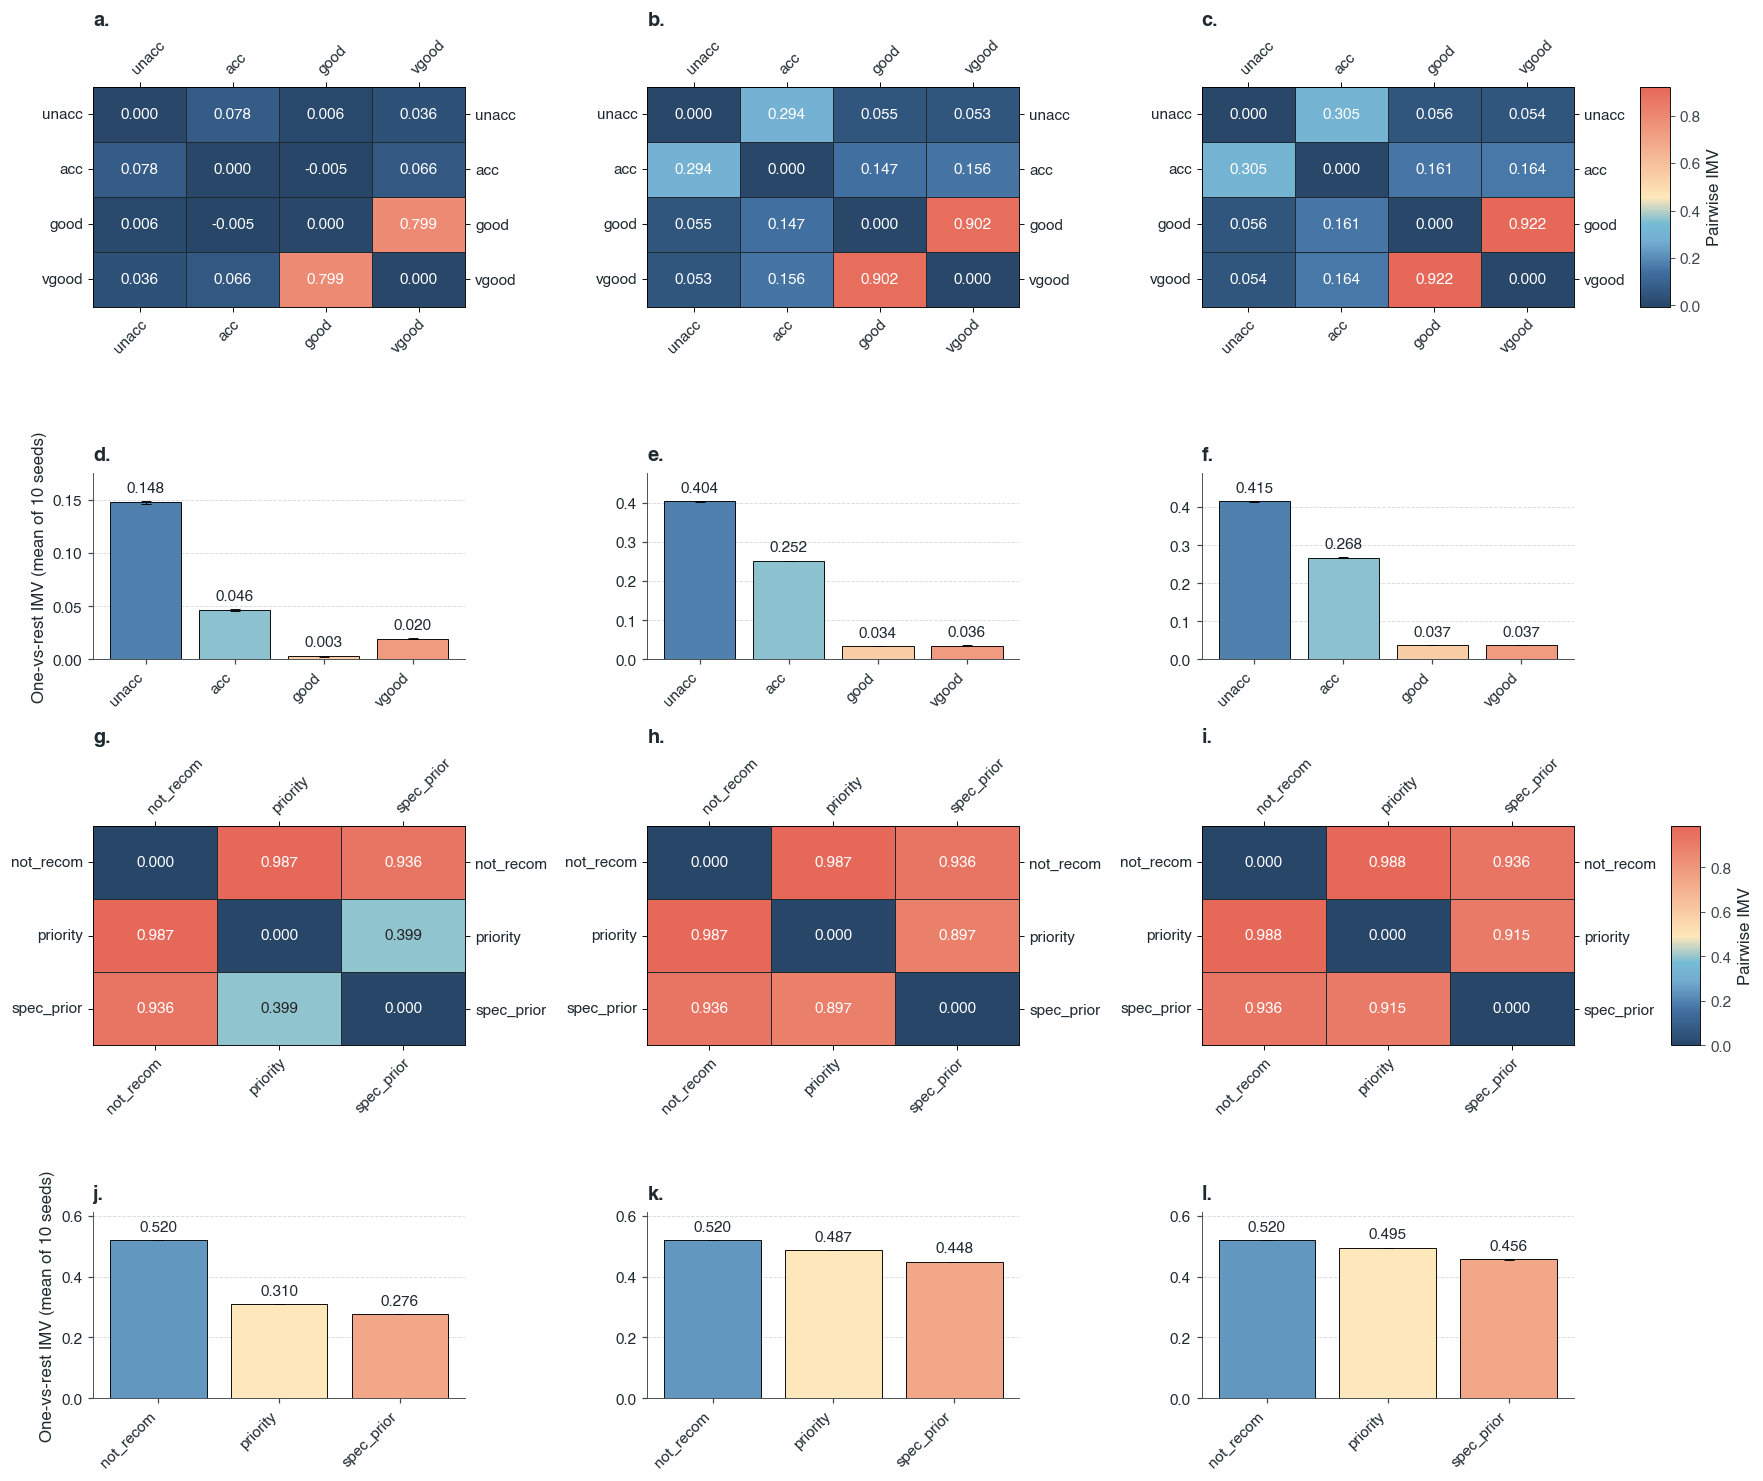

{'pdf': 'output/figures/figure_A4.pdf'}

In [ ]:
show_example("nursery")
show_multi_supplement()


### 2.6. Table 3 and additional LaTeX exports

Car Evaluation exports **Table 3** to `output/tables/multi_imv_car_evaluation.tex`, a complete float included by the main manuscript. Dry Bean and Nursery retain separate additional exports; exporting them does not insert them into the main paper.

Every table uses the same caption helper, booktabs rules, striped rows, bold Multi-IMV rows, and an unnumbered global-metrics note. The preamble requires `booktabs`, `xcolor` with the `table` option, `graphicx`, and `caption`.

The numbers match the displays above and come directly from the saved per-seed summaries. The caption distinguishes fold-averaged IMV from metrics computed on pooled out-of-fold predictions, and standard deviations from confidence intervals. Accuracy is one-vs-rest accuracy, not a duplicate of precision. Edit the caption helper below rather than the generated `.tex` files; rerunning this cell overwrites those exports.


In [ ]:
MULTI_N_SPLITS = 5                  # the fold count the three example notebooks run
MULTI_ROW_COLOR = "gray!15"
MULTI_TABLE_WIDTH = r"0.85\textwidth"
MULTI_MODEL_SHORT = {"logistic_regression": "LR", "xgboost": "XGB", "lightgbm": "LGBM"}
MULTI_CLASS_METRIC_LABELS = {"multi_imv": "Multi-IMV", "brier_loss": "Brier Loss",
                       "accuracy": "Accuracy", "precision": "Precision",
                       "recall": "Recall"}
MULTI_CLASS_PERCENT_METRICS = {"accuracy", "precision", "recall"}
# Class headings as the paper prints them; anything unlisted is title-cased.
MULTI_CLASS_DISPLAY_NAMES = {
    "car_evaluation": {"unacc": "Unacc", "acc": "Acc", "good": "Good",
                       "vgood": "Very good"},
    "nursery": {"not_recom": "Not recom.", "priority": "Priority",
                "spec_prior": "Spec. prior"},
}



def multi_class_heading(dataset, class_name):
    display = MULTI_CLASS_DISPLAY_NAMES.get(dataset, {}).get(
        class_name, class_name.replace("_", " ").title())
    return escape_latex(display)

def multi_latex_value(metric, mean, deviation, *, bold):
    scale = 100 if metric in MULTI_CLASS_PERCENT_METRICS else 1
    spread = 0.0 if pd.isna(deviation) else deviation
    body = f"{scale * mean:.2f}$\\pm${scale * spread:.2f}"
    return f"\\textbf{{{body}}}" if bold else body

def multi_latex_global_line(result, model):
    """One estimator's global metrics as the sentence under the tabular."""
    row = result["global_summary"].set_index("model").loc[model]
    cells = []
    for metric, label in MULTI_GLOBAL_LABELS.items():
        scale = 100 if metric in MULTI_PERCENT_METRICS else 1
        deviation = row[f"{metric}_std"]
        spread = 0.0 if pd.isna(deviation) else deviation
        cells.append(f"{label}: {scale * row[f'{metric}_mean']:.2f}"
                     f"$\\pm${scale * spread:.2f}")
    return f"Global metrics ({MULTI_MODEL_SHORT[model]}): " + "; ".join(cells) + "."

def multi_table_caption(result):
    """Shared protocol and units; manuscript numbering is assigned by LaTeX."""
    abbreviations = (" Unacc and Acc denote Unacceptable and Acceptable."
                     if result["dataset"] == "car_evaluation" else "")
    return (f"One-vs-rest Multi-IMV and classification performance on "
            f"{escape_latex(result['title'])}. LR, XGB, and LGBM denote logistic "
            f"regression, XGBoost, and LightGBM. Values are means "
            rf"$\pm$ one sample standard deviation across {result['n_seeds']} "
            f"seeds, each using {MULTI_N_SPLITS}-fold stratified cross-validation; "
            f"these are not confidence intervals. IMV compares the feature-based "
            f"model with the same estimator fitted to a constant input only. "
            f"IMV is averaged over folds within each seed; other metrics use "
            f"pooled out-of-fold predictions. Accuracy, precision, and recall "
            f"are percentages for each class versus the rest, using the "
            f"multiclass argmax prediction; undefined precision or recall is "
            f"set to zero. Brier Loss denotes Brier score loss on class "
            f"probabilities. Values are rounded to two decimals, so a displayed "
            f"zero standard deviation need not imply identical runs."
            f"{abbreviations}")

def multi_latex_table(result):
    """One example as a complete `table*` float."""
    dataset, class_names = result["dataset"], result["class_names"]
    summary = result["class_summary"].set_index(["model", "class"])
    headings = " & ".join(
        f"\\multicolumn{{1}}{{c}}{{\\bf{{{multi_class_heading(dataset, name)}}}}}"
        for name in class_names)

    rows = []
    for model in MULTI_MODEL_NAMES:
        for metric, label in MULTI_CLASS_METRIC_LABELS.items():
            # Multi-IMV is the row the table is about, so it carries the weight.
            bold = metric == "multi_imv"
            heading = f"{label} ({MULTI_MODEL_SHORT[model]})"
            heading = f"\\textbf{{{heading}}}" if bold else heading
            values = [multi_latex_value(metric, summary.loc[(model, index), f"{metric}_mean"],
                                  summary.loc[(model, index), f"{metric}_std"], bold=bold)
                      for index in range(len(class_names))]
            rows.append(f"{heading} & " + " & ".join(values) + r" \\")
    # Zebra striping runs every other row and carries on across the estimator
    # blocks, so the shading never lines up with a block boundary.
    rows = [f"\\rowcolor{{{MULTI_ROW_COLOR}}}{row}" if index % 2 else row
            for index, row in enumerate(rows)]

    global_block = "\n".join(
        ("" if index == 0 else r"\\") + multi_latex_global_line(result, model)
        for index, model in enumerate(MULTI_MODEL_NAMES))
    caption = multi_table_caption(result)

    return "\n".join([
        f"% Generated by {NOTEBOOK_PATH}; do not edit by hand.",
        r"% Requires: \usepackage{booktabs}, \usepackage[table]{xcolor}, "
        r"\usepackage{graphicx}, \usepackage{caption}.",
        r"\begin{table*}[htbp]",
        r"\centering",
        f"\\caption{{{caption}}}",
        f"\\label{{tab:MultiIMV{result['title'].replace(' ', '')}}}",
        f"\\resizebox{{{MULTI_TABLE_WIDTH}}}{{!}}{{",
        f"\\begin{{tabular}}{{l{'c' * len(class_names)}}}",
        r"\toprule",
        r"\multicolumn{1}{l}{{\bf{Methods}}} & " + headings + r"\\",
        r"\midrule",
        *rows,
        r"\bottomrule",
        r"\end{tabular}",
        "}",
        r"\caption*{\footnotesize\normalfont",
        global_block,
        r"\par F1, one-vs-rest AUC-ROC, and Jaccard use support-weighted class "
        r"averages. These three metrics and Cohen's kappa are multiplied by 100; "
        r"log loss and Hamming loss are unscaled.",
        "}",
        r"\end{table*}",
        "",
    ])

multi_latex_tables = {dataset: multi_latex_table(result) for dataset, result in multiclass_results.items()}
for dataset, text in multi_latex_tables.items():
    write_text_atomic(text, TABLES / f"multi_imv_{dataset}.tex")
    print(f"wrote {relative_path(TABLES / f'multi_imv_{dataset}.tex')}")

wrote output/tables/multi_imv_car_evaluation.tex
wrote output/tables/multi_imv_dry_bean.tex
wrote output/tables/multi_imv_nursery.tex


### The generated source

**Table 3 is the Car Evaluation block below.** The Dry Bean and Nursery blocks are additional exports. All three are written to `output/tables/multi_imv_<dataset>.tex`; only the Car Evaluation export is included as Table 3 in the main manuscript.


In [ ]:
for dataset, text in multi_latex_tables.items():
    print(f"% ---------- {dataset} "
          f"{'-' * max(0, 66 - len(dataset))}")
    print(text)

% ---------- car_evaluation ----------------------------------------------------
% Generated by src/empirical/plotter/plotter.ipynb; do not edit by hand.
% Requires: \usepackage{booktabs}, \usepackage[table]{xcolor}, \usepackage{graphicx}, \usepackage{caption}.
\begin{table*}[htbp]
\centering
\caption{One-vs-rest Multi-IMV and classification performance on Car Evaluation. LR, XGB, and LGBM denote logistic regression, XGBoost, and LightGBM. Values are means $\pm$ one sample standard deviation across 10 seeds, each using 5-fold stratified cross-validation; these are not confidence intervals. IMV compares the feature-based model with the same estimator fitted to a constant input only. IMV is averaged over folds within each seed; other metrics use pooled out-of-fold predictions. Accuracy, precision, and recall are percentages for each class versus the rest, using the multiclass argmax prediction; undefined precision or recall is set to zero. Brier Loss denotes Brier score loss on class pro

## 3. Ablate-IMV: what the panels measure

The single 2 x 3 overview is **Figure 4** in the manuscript. It replaces both former ablation figures (4 and 6), rather than repeating or splitting the three examples.

- **Heatmaps:** the mean of the saved seed-level ablation matrices. Rows are enhanced models; columns are basic models. Positive values favour the row. The current `imvpy` matrices are directional: opposite cells need not be negatives of one another. We preserve these values rather than mirror a triangle as in the paper's displayed matrices. All panels share one colour scale centred on zero.
- **Bars:** each full or ablated model versus the paper's **constant 0.5-probability baseline** (Section 4.4, Eq. 10). `imvpy.imv_from_likelihoods(0.5, likelihood)` transforms each saved seed-level geometric mean likelihood **before** taking the mean. These are not full-model-versus-ablation differences, nor accuracy scores.
- **Uncertainty:** whiskers are sample standard deviations (`ddof=1`) across seeds 42-51, not confidence intervals. Both rows retain the source notebook's variant order, with the full model first.

The baseline follows the paper even for an imbalanced task; it is not a prevalence-fitted null. MAGIC Gamma removes feature groups with a fixed MLP architecture; MNIST and HAR remove architectural components. No assumption is made that every ablation must reduce performance.

The loader requires all ten seeds and every variant/pair, rejects duplicate or non-finite results, and cross-checks pairwise IMVs against the likelihood diagnostics through `imvpy`. Incomplete or inconsistent source files fail with an actionable error.

Compact inputs are published under `output/examples/ablation_imv/`. The loader prefers the complete published pair for each example; if neither input is published it uses the external cache. Partial or inconsistent pairs raise errors instead of mixing different runs.


In [ ]:
ablation_results = [load_ablation_results(example, ARTIFACT_ROOT, project_root=PROJECT_ROOT)
                    for example in ABLATION_EXAMPLES]
pd.DataFrame([
    {
        'example': result.example.title,
        'source_notebook': f'src/empirical/ablation_imv/{result.example.notebook_stem}.ipynb',
        'seeds': len(result.seeds),
        'variants': len(result.example.variants),
        'result_files': ', '.join(path.name for path in result.source_paths),
    }
    for result in ablation_results
])

,example,source_notebook,seeds,variants,result_files
0,MNIST / CNN,src/empirical/ablation_imv/ablation_imv_mnist....,10,5,"mnist_ablation_imv_by_seed.csv, mnist_variant_..."
1,UCI HAR / BiGRU,src/empirical/ablation_imv/ablation_imv_har.ipynb,10,5,"har_ablation_imv_by_seed.csv, har_variant_diag..."
2,MAGIC Gamma / MLP,src/empirical/ablation_imv/ablation_imv_magic_...,10,5,"magic_gamma_ablation_imv_by_seed.csv, magic_ga..."


In [ ]:
bar_summary = pd.concat(
    {result.example.dataset: result.null_summary for result in ablation_results},
    names=['example', 'variant'],
)
bar_summary.rename(columns={'mean': 'mean_imv_vs_null', 'std': 'seed_sd', 'count': 'n_seeds'})

mean_imv_vs_null   seed_sd  n_seeds
example     variant                                             
mnist       FullCNN                  0.974878  0.027631       10
            NoConv2                  0.955596  0.014775       10
            NoHidden                 0.974729  0.004644       10
            NoDropout                0.980401  0.007133       10
            Linear                   0.751424  0.079001       10
har         FullBiGRU                0.918786  0.051443       10
            UniGRU                   0.897073  0.056798       10
            OneLayer                 0.909113  0.048400       10
            NoAttention              0.929892  0.031127       10
            MeanPoolMLP              0.411342  0.025442       10
magic_gamma FullFeatures             0.815500  0.006766       10
            NoGeometry               0.775652  0.006256       10
            NoConcentration          0.758893  0.008791       10
            NoMoments                0.815057  0.005401       10
            NoOrientation            0.701259  0.010048       10

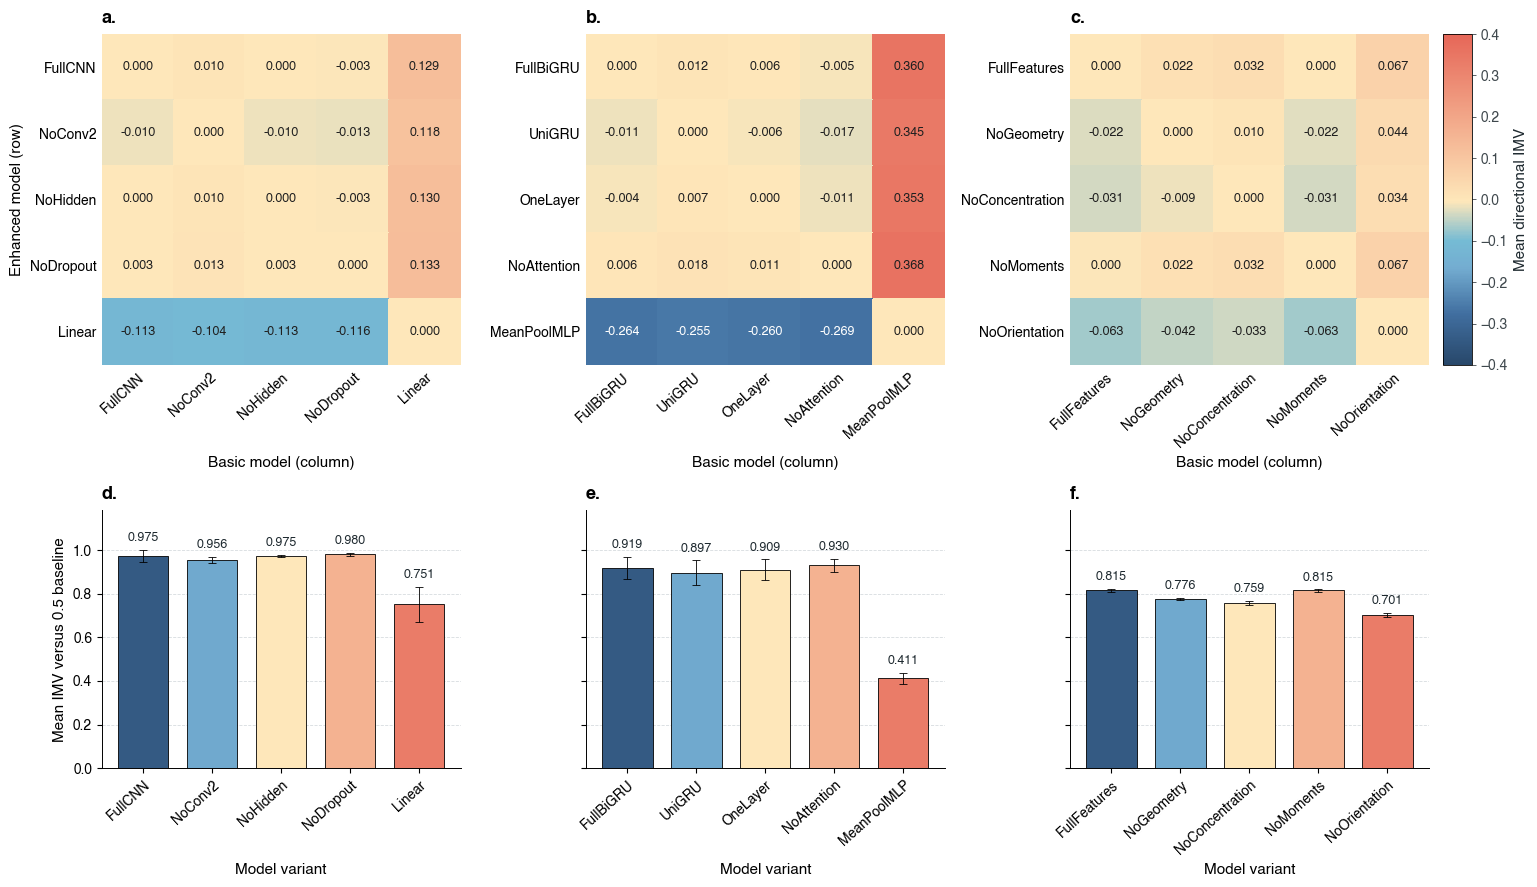

{'pdf': 'output/figures/figure_4.pdf'}

In [ ]:
def show_ablation_figure():
    """Export all three examples as Figure 4, replacing the old overview name."""
    figure, axes = plot_ablation_overview(ablation_results)
    try:
        paths = save_publication_figure(figure, FIGURES / FIGURE_NAME)
        # Retire the duplicate overview only after the numbered PDF saves.
        (FIGURES / "ablation_imv__mnist_har_magic_gamma__overview.pdf").unlink(missing_ok=True)
        plt.show()
    finally:
        plt.close(figure)
    return {file_format: relative_path(path) for file_format, path in paths.items()}

ablation_figure_paths = show_ablation_figure()
ablation_figure_paths


### Ablation export and suggested caption

Exports: `output/figures/figure_4.pdf`. Only PDF is saved, using Helvetica, the shared project palette, vector cells and a vector colourbar, with no embedded heatmap images. `IMV_FIGURE_DIR` overrides the destination, and `IMV_ARTIFACT_CACHE` / `IMV_CACHE_HOME` select existing results using the source notebooks' conventions.

From the repository root, rebuild all figures in this notebook with:

```bash
python -m nbconvert --execute --to notebook --inplace --ExecutePreprocessor.kernel_name=imv-ml src/empirical/plotter/plotter.ipynb
```

**Suggested caption for Figure 4.** Ablate-IMV across three binary classification tasks. Columns show MNIST odd-versus-even digits with a CNN, UCI HAR upstairs-versus-downstairs activity with a bidirectional GRU, and MAGIC Gamma gamma-versus-hadron events with an MLP, respectively. Panels **a.**, **b.**, and **c.** show directional pairwise IMV: rows are enhanced models and columns are basic models, so positive values favour the row model. Opposite entries need not be negatives of one another; the three heatmaps share a colour scale centred on zero. Panels **d.**, **e.**, and **f.** show each full or ablated model's IMV relative to constant 0.5-probability predictions, not its difference from the full model. Cell annotations and bar heights are means of ten seed-level scores (seeds 42-51); whiskers denote one sample standard deviation across seeds, not confidence intervals. The full model appears first in every panel. MNIST and HAR ablate architectural components, while MAGIC Gamma removes feature groups with the MLP hidden architecture held fixed. All scores use held-out predictions, with test observations aligned across variants within each seed.


## 4. GNN training: six examples from Section 6 and Appendix F.3

The source notebook is `src/empirical/gnn/gnn_training.ipynb`. The complete 2 x 3 overview is now **Figure 5**, combining the original main/appendix dataset order: PROTEINS, NCI1, NCI109, Mutagenicity, AIDS, DD.

IMV is the emphasized curve. Accuracy, precision and recall are plotted from the same held-out test predictions. Precision/recall are binary for canonical class 1 at threshold 0.5, per Appendix E.2.2. The IMV null predicts **training prevalence**, unlike the ablation figure's 0.5 null.

Lines show the mean across ten seeds. A shaded band follows the minimum and maximum seed values at every epoch along each mean curve, separately for each dataset and metric; individual seed lines are omitted from this overview. These are observed seed ranges, not confidence intervals or SD bands. Every epoch is plotted, with no smoothing or renderer path simplification; negative IMV remains visible. Undefined IMV creates a gap in both the mean and range rather than using fewer seeds. The table below reports finite-seed coverage. Ranges are calculated directly from saved metrics; the original CI description in training manifests does not control plotting.


In [ ]:
from empirical.gnn.gnn_results import load_gnn_results, plot_gnn_learning_curves, plot_gnn_seed_curves

gnn = load_gnn_results(ARTIFACT_ROOT)
gnn.summary.query("split == 'test' and metric == 'imv'").groupby("dataset", sort=False).agg(
    minimum_valid_seeds=("n_valid", "min"),
    complete_epochs=("n_valid", lambda counts: int((counts == 10).sum())),
)


,minimum_valid_seeds,complete_epochs
dataset,,
PROTEINS,10,201
NCI1,10,201
NCI109,10,201
Mutagenicity,10,201
AIDS,10,201
DD,10,201


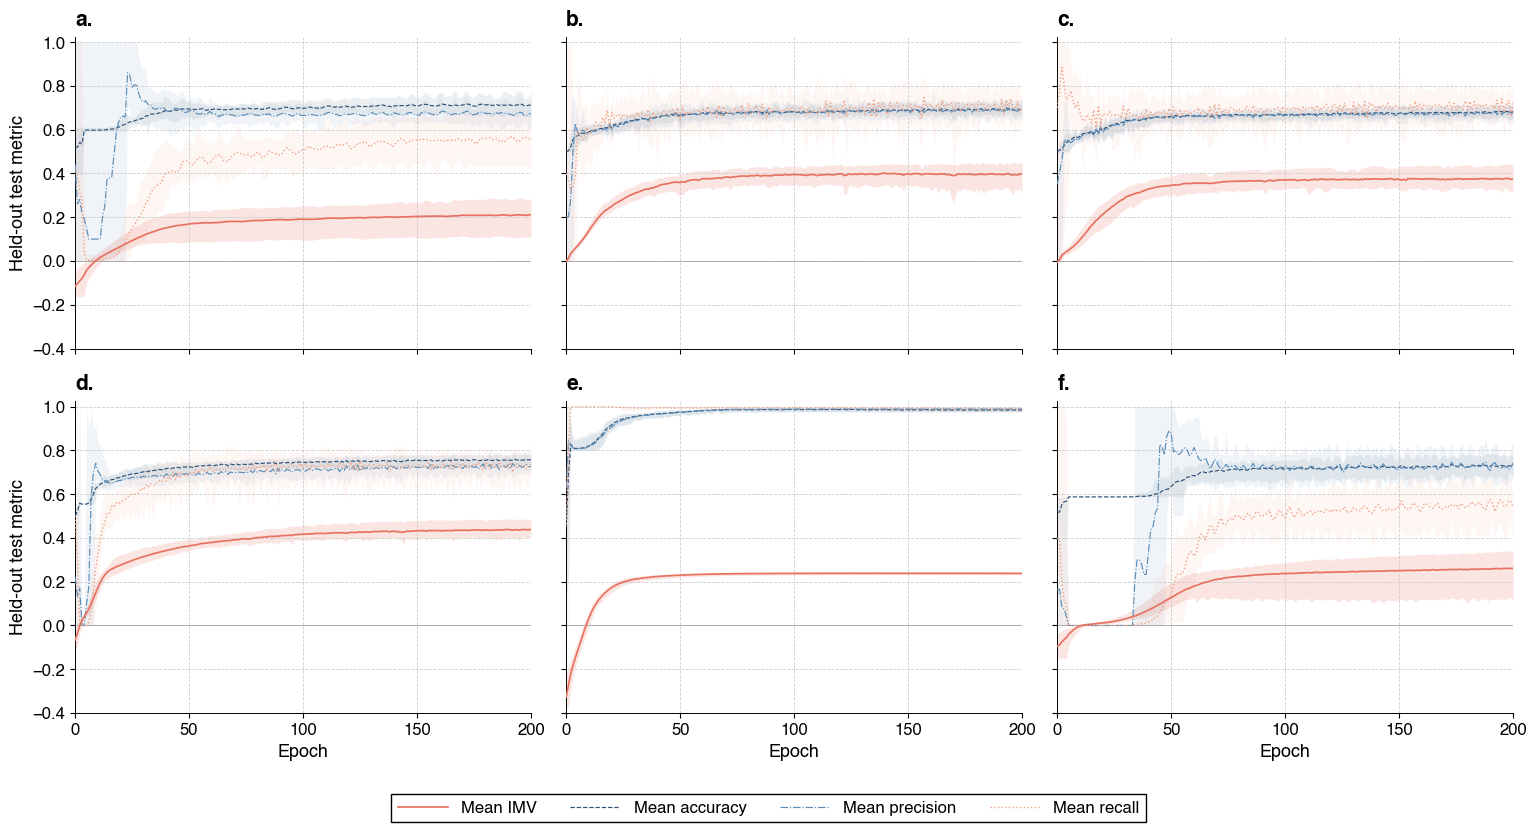

{'pdf': 'output/figures/figure_5.pdf'}

In [ ]:
GNN_FIGURE_NAME = "figure_5"

def show_gnn_figure():
    """Export the six-dataset means and per-epoch seed ranges as Figure 5."""
    figure, axes = plot_gnn_learning_curves(gnn)
    try:
        paths = save_publication_figure(figure, FIGURES / GNN_FIGURE_NAME)
        # Retire the duplicate descriptive filename only after the PDF saves.
        (FIGURES / "gnn_training__six_datasets__learning_curves.pdf").unlink(missing_ok=True)
        plt.show()
    finally:
        plt.close(figure)
    return {file_format: relative_path(path) for file_format, path in paths.items()}

gnn_figure_paths = show_gnn_figure()
gnn_figure_paths


In [86]:
gnn.summary.query("split == 'test' and epoch == 200").pivot(
    index="dataset", columns="metric", values="mean"
).reindex(gnn.manifest["datasets"])


metric,accuracy,balanced_accuracy,brier,f1,imv,log_loss,precision,recall,roc_auc
dataset,,,,,,,,,
PROTEINS,0.711377,0.684887,0.200066,0.603413,0.212052,0.587760,0.674938,0.548310,0.734824
NCI1,0.694003,0.693989,0.204864,0.696626,0.397838,0.609488,0.692744,0.702589,0.747890
NCI109,0.684194,0.683895,0.210973,0.699340,0.374870,0.616893,0.673002,0.730128,0.732406
Mutagenicity,0.757604,0.755364,0.164066,0.729687,0.438739,0.502693,0.725695,0.734828,0.836639
AIDS,0.984000,0.973125,0.012072,0.990014,0.237739,0.054440,0.988840,0.991250,0.993840
DD,0.732203,0.703109,0.190149,0.622014,0.261581,0.568681,0.742695,0.536986,0.761301


**Suggested caption for Figure 5.** Held-out test performance during training of a three-layer graph convolutional network on six TU graph-classification benchmarks: **a.** PROTEINS (1,113 graphs), **b.** NCI1 (4,110), **c.** NCI109 (4,127), **d.** Mutagenicity (4,337), **e.** AIDS (2,000), and **f.** DD (1,178). Lines show the mean IMV, accuracy, precision, and recall across ten independent runs (seeds 42-51); shaded bands span the minimum and maximum seed values at each epoch, rather than confidence intervals. Each run uses a seed-specific stratified 70/15/15 training/validation/test split and 200 training epochs. Epoch 0 denotes the untrained model. IMV compares the model's predicted probabilities with a constant-probability null estimated from training-set prevalence. Accuracy, binary precision, and binary recall use a probability threshold of 0.5, with class 1 treated as positive. All epochs are shown without temporal smoothing or renderer path simplification, and negative IMV values are retained.

**Methods note.** This is a documented reconstruction rather than an assertion of exact numerical replication of the paper; the source training notebook distinguishes specified settings from implementation choices.

PDF: `output/figures/figure_5.pdf`.


### Inspect the seed heterogeneity directly

A seed mean can hide opposing epoch-to-epoch changes even without temporal smoothing. The original reference averaged five seeds; this study uses ten. The overview's common y-axis includes all four metrics and negative epoch-0 IMV, so small changes also occupy less vertical space than in the paper. Thick lines previously obscured small fluctuations, and Matplotlib's [default path simplification](https://matplotlib.org/3.7.3/users/explain/performance.html) was enabled. The plotter now disables simplification and uses thinner means with shaded min-max bands; individual trajectories are available only in the separate diagnostic below.

The diagnostic below draws all ten raw IMV trajectories, with **no seed averaging** and **independent, explicitly labelled y-axis ranges**. It includes every saved epoch, not just checkpoints. The following table measures absolute consecutive-epoch changes from epoch 100 to 200; it is descriptive, not a convergence test or smoothing operation. No seeds are chosen based on their appearance. Undefined values propagate rather than being discarded.

The remaining numerical differences from the paper cannot be attributed precisely without its original GNN code: hidden width, optimizer, pooling, dropout, feature handling, exact splits and the Section 6 null were not all specified. Those reconstruction choices remain fixed; they are not adjusted to manufacture fluctuations. Use `plot_gnn_seed_curves(gnn, metric='accuracy')` (or `precision` / `recall`) to inspect the other metrics in the same format.

**Suggested diagnostic figure caption.** Individual-seed IMV trajectories on **a.** PROTEINS, **b.** NCI1, **c.** NCI109, **d.** Mutagenicity, **e.** AIDS, and **f.** DD. Each coloured line represents one of ten independent runs (seeds 42-51), under the same protocol as the mean-and-range figure. All 201 evaluated epochs, including the untrained epoch 0, are shown without seed averaging, temporal smoothing, or renderer path simplification. IMV is measured against the training-prevalence null. Y-axis ranges vary across panels to expose within-run changes; numerical comparisons should use the tick labels.


In [87]:
import numpy as np

seed_variation = []
for dataset in gnn.manifest['datasets']:
    trajectories = gnn.epochs.query("dataset == @dataset and split == 'test'").pivot(
        index='epoch', columns='seed', values='imv'
    ).sort_index()
    assert trajectories.shape == (201, 10)
    np.testing.assert_array_equal(trajectories.index, np.arange(201))
    values = trajectories.loc[100:200].to_numpy()
    steps = np.diff(values, axis=0)
    seed_variation.append({
        'dataset': dataset,
        'epochs_per_seed': len(trajectories),
        'mean_abs_individual_seed_step': np.abs(steps).mean(),
        'mean_abs_ten_seed_mean_step': np.abs(np.diff(values.mean(axis=1))).mean(),
        'largest_abs_individual_seed_step': np.abs(steps).max(),
    })
pd.DataFrame(seed_variation).set_index('dataset')


,epochs_per_seed,mean_abs_individual_seed_step,mean_abs_ten_seed_mean_step,largest_abs_individual_seed_step
dataset,,,,
PROTEINS,201,0.001401,0.000507,0.008555
NCI1,201,0.005500,0.001745,0.053091
NCI109,201,0.004660,0.001697,0.045315
Mutagenicity,201,0.003361,0.001157,0.030546
AIDS,201,0.000301,0.000122,0.002332
DD,201,0.002287,0.000897,0.020471


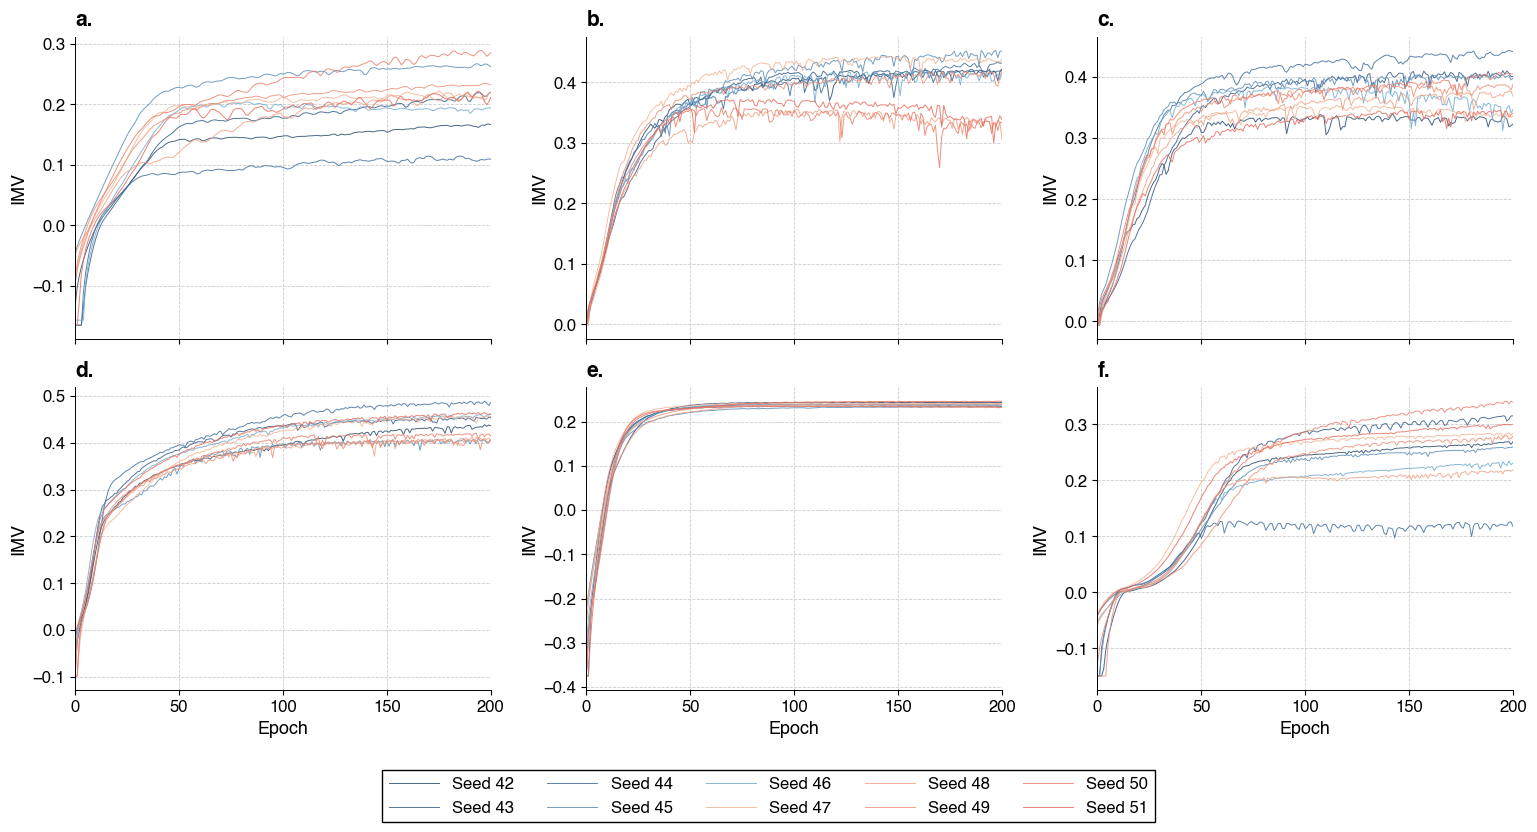

PDF: /home/jinx/CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/new/IMV_ML/output/figures/gnn_training__six_datasets__individual_seed_imv.pdf


In [88]:
seed_fig, seed_axes = plot_gnn_seed_curves(gnn, metric='imv')
seed_paths = save_publication_figure(
    seed_fig, FIGURES / 'gnn_training__six_datasets__individual_seed_imv'
)
plt.show()
plt.close(seed_fig)
print('PDF:', seed_paths['pdf'])
